# London Flip Finder

**End-to-end valuation and mispricing detection for the London residential market (2008–2016).**

This notebook is the *entire* project. It is organised as a sequence of small, pure functions —
each stage takes data in and returns data out, so any cell can be re-run without corrupting
another cell's state, and the whole notebook is deterministic given `CONFIG.seed`.

| Stage | Sections | What happens |
|---|---|---|
| Setup | 1–3 | Imports, one `CONFIG` object, self-bootstrapping data download |
| Data | 4–7 | Load, clean, spatially join, merge into one master table |
| Analysis | 8 | Exploratory data analysis |
| Features | 9–10 | Temporal/market engineering, leakage-safe four-way chronological split |
| Models | 11–13 | Ridge → XGBoost/CatBoost (plain and detrended) → two Mixture-of-Experts designs |
| Decision | 14–16 | Test evaluation, target-transform and feature-group experiments, conformal safety bound, flip scanner |
| Assurance | 17–18 | Automated self-checks, persisted artifacts, known limitations |

**The business question.** Given a property's physical, spatial, temporal and macroeconomic
context, what is it worth — and can we identify listings priced below a *statistically
guaranteed* floor, so that a buyer has a quantified margin of safety?

**What the finished pipeline found** (full run, 59,946 transactions):

| | |
|---|---|
| Selected on validation (§14) | `3-seed average detrended (XGB)` — **13.30 %** test MdAPE |
| Best single model | `XGBoost detrended-market (capped)` — 13.12 % val → 13.48 % test |
| Ridge (baseline) | 16.72 % test — beaten by 3.4 pp |
| Conformal floor | prediction × **0.7484**, **88.96 %** empirical coverage vs a 90 % target |
| Flip candidates | 978 of 8,859 test properties (11.04 %), median margin £76,166 |
| Crime ablation (§14.5) | removing crime costs **+0.01 pp** validation MdAPE — far below the 0.15 pp bar, so crime does **not** justify the narrow window |

Six findings shape the modelling decisions that follow:

1. **The tree models' deficit against Ridge is a target problem, not an architecture problem.** A
   tree's prediction is a leaf constant, so it cannot extrapolate a rising market past the last
   price level it saw in training — measured on **validation** (§12.2), plain XGBoost under-predicts
   by a mean of +£78,782, against Ridge's +£52,225. Section 12.1 addresses this by predicting
   `log(price / market level)` instead of `log(price)`, turning an extrapolation problem into an
   interpolation one and cutting that bias to +£20,873. On the detrended target XGBoost beats Ridge
   by 3.2 pp of test MdAPE, having lost to it by 5.9 pp on the plain one. The nuance §12.2 makes
   visible: Ridge is *also* biased by the same mechanism, just less — the target, not the
   architecture, is what separates them.
2. **A finer-grained deflator is worse than a market-wide one.** Section 14.3 tests a more targeted
   version of the same fix — deflating by borough-and-size rather than by the whole market — and it
   loses for both backends. `lagged_borough_median_sqm` is estimated from far fewer sales per month
   than the market-wide median, and a noisier deflator injects that noise directly into every
   training label. The coarser, simpler deflator wins on both validation and test.
3. **Split geometry is a secondary effect, not the primary one.** The four-way split does move
   validation away from test, and that cost is real (see section 14's discussion) — but it is not
   what drives the gap between Ridge and the trees. The detrended trees use the *identical* split
   and still recover almost all their accuracy, so the non-stationary target accounts for most of
   the damage.
4. **Ensembling helps a little; the routing on top of it does not.** On the detrended base (§14.4),
   a plain 3-seed average beats the best single model by 0.18 pp of test MdAPE and error-driven
   routing by 0.14 pp — but routing does not beat its own averaging control (−0.005 pp on
   validation). Luxury routing is worse than all of them, by 0.64 pp. The gain comes from averaging
   several seeds, which is nearly free, not from the router that is the architecturally interesting
   part.
5. **Crime does not justify the 2008–2016 window.** Scored on validation and on the recipe actually
   shipped, removing crime costs **+0.01 pp** of MdAPE — far below the 0.15 pp bar set in §14.5,
   even though that one feature group is what caps the modelling window and discards 80 % of the
   available sale records. Measured instead on the *test* set and on the *plain* target, the same
   ablation returns +0.46 pp; that inflated figure is the feature partially compensating for the
   extrapolation bias in finding 1 rather than contributing signal of its own. The recommendation
   is to widen the window.
6. **Anomaly removal is close to a no-op.** With the `cleaned` variant removing only the 2 % of
   rows the IsolationForest flags (section 10), `capped` and `cleaned` land within noise of each
   other: `capped` is 0.10 pp better on validation, `cleaned` 0.15 pp better on test. The
   defensible conclusion is the narrow one — anomalies must never be removed from the *evaluation*
   set, but removing them from training changes little here.

## Contents

- [1. Imports and environment](#1-imports-and-environment)
- [2. Configuration](#2-configuration)
- [3. Data acquisition](#3-data-acquisition)
- [4. Loading the raw sources](#4-loading-the-raw-sources)
- [5. Cleaning and per-source feature construction](#5-cleaning-and-per-source-feature-construction)
- [6. Spatial engineering](#6-spatial-engineering)
- [7. Building the master table](#7-building-the-master-table)
- [8. Exploratory data analysis](#8-exploratory-data-analysis)
  - [8.1 Spatial, safety and macroeconomic drivers](#81-spatial-safety-and-macroeconomic-drivers)
- [9. Temporal and market feature engineering](#9-temporal-and-market-feature-engineering)
- [10. Chronological partitioning and encoding](#10-chronological-partitioning-and-encoding)
- [11. Metrics](#11-metrics)
- [12. Models](#12-models)
  - [12.1 Detrending the target: a fix, not just a diagnosis](#121-detrending-the-target-a-fix-not-just-a-diagnosis)
  - [12.2 The same diagnosis, reached without the test set](#122-the-same-diagnosis-reached-without-the-test-set)
- [13. Validation leaderboard](#13-validation-leaderboard)
- [14. Held-out test evaluation](#14-held-out-test-evaluation)
  - [14.1 Repeat-property diagnostic](#141-repeat-property-diagnostic)
  - [14.2 Error diagnostics and feature importance](#142-error-diagnostics-and-feature-importance)
  - [14.3 Choosing a target transform: three options, tested head to head](#143-choosing-a-target-transform-three-options-tested-head-to-head)
  - [14.4 Is the Mixture of Experts needed, once the base model is fixed?](#144-is-the-mixture-of-experts-needed-once-the-base-model-is-fixed)
  - [14.5 Feature-group ablation: is crime worth what it costs?](#145-feature-group-ablation-is-crime-worth-what-it-costs)
- [15. Conformal safety bound and the flip scanner](#15-conformal-safety-bound-and-the-flip-scanner)
- [16. Persisting the run](#16-persisting-the-run)
- [17. Automated self-checks](#17-automated-self-checks)
- [18. Limitations and where to take this next](#18-limitations-and-where-to-take-this-next)

---
## 1. Imports and environment

Every import used in this notebook lives in this one cell. No cell below re-imports anything, and
no cell installs packages at runtime — dependencies come from `requirements.txt` (see `README.md`).

Warnings are filtered *narrowly* rather than with a blanket `filterwarnings('ignore')`, so genuine
problems still surface.

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
import warnings
import zipfile
from collections.abc import Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable

import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from catboost import CatBoostRegressor
from scipy.optimize import minimize
from scipy.spatial import cKDTree
from shapely.geometry import Point
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Narrow, intentional warning filters -- not a blanket silence.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", message=".*is_sparse is deprecated.*")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

GBP = ticker.FuncFormatter(lambda x, _: f"\N{POUND SIGN}{int(x):,}")
THOUSANDS = ticker.FuncFormatter(lambda x, _: f"{int(x):,}")

print(f"python      {sys.version.split()[0]}")
for _mod in (np, pd, gpd, xgb):
    print(f"{_mod.__name__:<12}{_mod.__version__}")
import catboost  # noqa: E402  -- imported here purely to report its version
import sklearn  # noqa: E402

print(f"{'sklearn':<12}{sklearn.__version__}")
print(f"{'catboost':<12}{catboost.__version__}")

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/dsi/giladaviv/london_flip_finder/venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/dsi/giladaviv/london_flip_finder/venv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/dsi/giladaviv/london_flip_finder/venv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/dsi/giladaviv/london_flip_finder/venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/dsi/giladaviv/london_flip_finder/venv/lib64/python3.9/site-packages/traitlets/trai

python      3.9.25
numpy       1.26.4
pandas      2.3.3
geopandas   1.0.1
xgboost     2.1.4
sklearn     1.6.1
catboost    1.2.10


---
## 2. Configuration

A single frozen `Config` object is the only source of truth for paths, filters, split ratios and
hyper-parameters. Nothing below hardcodes a threshold — change a value here and re-run.

`FAST_MODE` shrinks every model's iteration budget so the whole notebook executes in a couple of
minutes for a smoke test; set `LFF_FAST_MODE=1` in the environment to enable it.

**Data location** is resolved in this order: `$LFF_DATA_DIR` → Google Drive (when running on
Colab) → `./data/data_for_ds_project`. Section 3 downloads the data if it is not there.

In [2]:
def resolve_data_dir() -> Path:
    """Locate the dataset directory: env var, then Colab Drive, then a local ./data folder."""
    env = os.environ.get("LFF_DATA_DIR")
    if env:
        return Path(env).expanduser()
    if "google.colab" in sys.modules:  # pragma: no cover - Colab only
        from google.colab import drive

        drive.mount("/content/drive")
        return Path("/content/drive/MyDrive/data_for_ds_project")
    return Path.cwd() / "data" / "data_for_ds_project"


@dataclass(frozen=True)
class Config:
    """Every tunable in the project. Frozen so a stage cannot mutate it by accident."""

    data_dir: Path = field(default_factory=resolve_data_dir)
    artifact_dir: Path = field(default_factory=lambda: Path.cwd() / "artifacts")
    dataset_url: str = (
        "https://github.com/GiladAviv/LondonFlipFinder/releases/download/v1.0.0/"
        "data_for_ds_project-20260629T125106Z-3-001.zip"
    )

    # Coordinate reference systems. BNG is metric, which makes distances interpretable.
    wgs84: str = "EPSG:4326"
    bng: str = "EPSG:27700"

    # Row filters
    year_min: int = 2008
    year_max: int = 2016
    min_price_per_sqm: float = 1_500.0   # drops symbolic transfers / data-entry errors
    price_cap: float = 4_000_000.0       # boundary of the "standard" market
    iso_contamination: float = 0.02      # IsolationForest anomaly rate (training data only)

    # Splitting and modelling. Four chronological slices: train fits the model, val drives
    # early stopping, model selection and every design decision in section 14, calib is touched
    # by nothing except conformal calibration (so q_10 is never computed on data the model was
    # tuned against), and test is read for reporting only -- never to fit or choose anything.
    # test_frac is the remainder.
    train_frac: float = 0.60
    val_frac: float = 0.15
    calib_frac: float = 0.10
    luxury_threshold: float = 1_000_000.0
    target_encoding_smoothing: int = 10
    conformal_alpha: float = 0.10        # -> 90% lower bound
    seed: int = 42
    fast_mode: bool = field(default_factory=lambda: os.environ.get("LFF_FAST_MODE") == "1")

    # --- derived paths -------------------------------------------------------
    @property
    def houses_csv(self) -> Path:
        return self.data_dir / "kaggle_london_house_price_data.csv"

    @property
    def crime_csv(self) -> Path:
        return self.data_dir / "london_crime_by_lsoa.csv"

    @property
    def boe_csv(self) -> Path:
        return self.data_dir / "Bank Rate history and data  Bank of England Database.csv"

    @property
    def stations_csv(self) -> Path:
        return self.data_dir / "TFL Entry and Exit Data" / "Geodata" / "Stations_20220221.csv"

    @property
    def boroughs_shp(self) -> Path:
        return self.data_dir / "London_Wards" / "Boroughs" / "London_Borough_Excluding_MHW.shp"

    @property
    def cache_parquet(self) -> Path:
        return self.artifact_dir / "master_table.parquet"

    @property
    def required_files(self) -> list[Path]:
        return [self.houses_csv, self.crime_csv, self.boe_csv, self.stations_csv, self.boroughs_shp]

    # --- iteration budgets ---------------------------------------------------
    @property
    def n_estimators(self) -> int:
        return 120 if self.fast_mode else 1000

    @property
    def n_expert_estimators(self) -> int:
        return 100 if self.fast_mode else 600

    @property
    def catboost_iterations(self) -> int:
        return 120 if self.fast_mode else 1000

    @property
    def test_frac(self) -> float:
        return 1.0 - self.train_frac - self.val_frac - self.calib_frac


CONFIG = Config()
CONFIG.artifact_dir.mkdir(parents=True, exist_ok=True)


def set_seeds(seed: int) -> None:
    """Make the run reproducible."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


set_seeds(CONFIG.seed)

print(f"data_dir     {CONFIG.data_dir}")
print(f"artifact_dir {CONFIG.artifact_dir}")
print(f"fast_mode    {CONFIG.fast_mode}")
print(f"split        {CONFIG.train_frac:.0%} train / {CONFIG.val_frac:.0%} val / "
      f"{CONFIG.calib_frac:.0%} calib / {CONFIG.test_frac:.0%} test")

data_dir     /home/dsi/giladaviv/london_flip_finder/data/data_for_ds_project
artifact_dir /home/dsi/giladaviv/london_flip_finder/artifacts
fast_mode    False
split        60% train / 15% val / 10% calib / 15% test


---
## 3. Data acquisition

The datasets total ~1.8 GB, which is far past GitHub's file limit, so they ship as a release
asset rather than living in the repository. This cell makes the notebook self-bootstrapping: if
the files are missing it downloads and extracts them, and if they are already present it does
nothing. That is what makes the notebook runnable on a fresh machine or a fresh Colab session
without any manual setup steps.

In [3]:
def ensure_dataset(cfg: Config) -> None:
    """Download + extract the release archive unless every required file is already present."""
    missing = [p for p in cfg.required_files if not p.exists()]
    if not missing:
        print(f"All {len(cfg.required_files)} required inputs present in {cfg.data_dir}")
        return

    print(f"Missing {len(missing)} input(s); fetching the dataset archive...")
    for p in missing:
        print(f"   - {p.relative_to(cfg.data_dir) if cfg.data_dir in p.parents else p}")

    import requests  # local import: only needed on the download path

    target_root = cfg.data_dir.parent
    target_root.mkdir(parents=True, exist_ok=True)
    archive = target_root / "dataset.zip"

    with requests.get(cfg.dataset_url, stream=True, timeout=120) as resp:
        resp.raise_for_status()
        total = int(resp.headers.get("content-length", 0))
        done = 0
        with open(archive, "wb") as fh:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                fh.write(chunk)
                done += len(chunk)
                if total:
                    print(f"\r   {done / 1e6:7.1f} / {total / 1e6:.1f} MB", end="")
    print("\n   extracting...")
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(target_root)
    archive.unlink()

    still_missing = [p for p in cfg.required_files if not p.exists()]
    if still_missing:
        raise FileNotFoundError(
            "Dataset archive did not contain the expected files. Missing:\n  "
            + "\n  ".join(str(p) for p in still_missing)
        )
    print(f"Dataset ready in {cfg.data_dir}")


ensure_dataset(CONFIG)

All 5 required inputs present in /home/dsi/giladaviv/london_flip_finder/data/data_for_ds_project


---
## 4. Loading the raw sources

Four sources feed the model:

| Source | Grain | Contributes |
|---|---|---|
| Land-Registry-derived price history | one row per sale event | target price + physical attributes |
| Met Police crime by LSOA | LSOA × category × month | neighbourhood safety |
| Bank of England base rate | one row per rate change | cost of borrowing |
| TfL station geodata | one row per station | transport connectivity |

Two deliberate exclusions:

* **`open_postcode_geo.csv` (300 MB) and the school scorecards are not loaded.** The original
  notebook read both — the postcode file costs ~1 GB of RAM — but neither ever reached a feature.
  Set `LOAD_OPTIONAL = True` if you want to revive them.
* **The `saleEstimate_*` and `rentEstimate_*` columns are not read.** They are a third party's
  *model output* for the same property, so using them to predict price would be target leakage
  dressed up as a feature.

The crime file is 13.5 M rows / 933 MB on disk. Reading it with explicit `usecols` and narrow
dtypes brings it down to ~110 MB in memory and under ten seconds.

In [4]:
LOAD_OPTIONAL = False  # postcode-geo + school scorecards: loaded by the original, never used

HOUSE_COLUMNS = [
    "fullAddress", "postcode", "outcode", "latitude", "longitude",
    "bathrooms", "bedrooms", "livingRooms", "floorAreaSqM",
    "tenure", "propertyType", "currentEnergyRating", "history_date", "history_price",
]
CRIME_DTYPES = {"borough": "category", "value": "int32", "year": "int16", "month": "int8"}


def load_raw(cfg: Config) -> dict[str, pd.DataFrame]:
    """Read every input we actually model on. Returns plain DataFrames, no side effects."""
    started = time.time()

    houses = pd.read_csv(cfg.houses_csv, usecols=HOUSE_COLUMNS)
    crime = pd.read_csv(cfg.crime_csv, usecols=list(CRIME_DTYPES), dtype=CRIME_DTYPES)
    boe = pd.read_csv(cfg.boe_csv)
    stations = pd.read_csv(cfg.stations_csv)

    raw = {"houses": houses, "crime": crime, "boe": boe, "stations": stations}

    if LOAD_OPTIONAL:  # pragma: no cover - opt-in path
        raw["postcodes"] = pd.read_csv(cfg.data_dir / "open_postcode_geo.csv", low_memory=False)
        scorecards = sorted(
            (cfg.data_dir / "local-authority-school-places-scorecards_2022" / "data").glob("*.csv")
        )
        raw["schools"] = pd.read_csv(scorecards[0], low_memory=False)

    print(f"Loaded {len(raw)} sources in {time.time() - started:.1f}s")
    for name, frame in raw.items():
        mem = frame.memory_usage(deep=True).sum() / 1e6
        print(f"   {name:<10} {len(frame):>12,} rows x {frame.shape[1]:>2} cols  ({mem:6.0f} MB)")
    return raw


RAW = load_raw(CONFIG)

Loaded 4 sources in 18.1s
   houses          418,201 rows x 14 cols  (   225 MB)
   crime        13,490,604 rows x  4 cols  (   108 MB)
   boe                 246 rows x  2 cols  (     0 MB)
   stations            471 rows x 14 cols  (     0 MB)


---
## 5. Cleaning and per-source feature construction

Three independent, pure transformations — each takes one raw frame and returns a tidy one.

**Crime is engineered with two lags, never with contemporaneous data.** `crime_volume` is the
month immediately *before* the sale (a short-term safety signal), and `crime_volume_prev_12m` is
the rolling twelve-month sum computed with `closed='left'` so the current month is excluded (a
stable "reputation" signal). Both are strictly backward-looking, which is what a buyer standing
at the transaction date could actually have known.

**Interest rates** arrive as a sparse list of change dates, forward-filled onto a daily calendar so
every sale is matched to the rate in force on the day it completed. Forward-fill *only*: the first
day of the window is seeded from the last change at or before it, and days with no prior rate stay
NaN. Back-filling is deliberately not used: it would stamp the first in-window rate onto every
day preceding it, assigning a rate to dates before it had been announced.

In [5]:
def clean_houses(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Normalise the price-history file and restrict it to the modelling window."""
    out = df.copy()
    out["date"] = pd.to_datetime(out["history_date"])
    out = out.rename(columns={"history_price": "price"})
    out = out[out["date"].dt.year.between(cfg.year_min, cfg.year_max)]
    out["postcode"] = out["postcode"].astype(str).str.replace(" ", "", regex=False).str.upper()

    # Scale of the dwelling. Kept NaN-aware: the gradient-boosted models consume NaN natively.
    out["total_rooms"] = out["bedrooms"] + out["livingRooms"]

    before = len(out)
    out = out.dropna(subset=["floorAreaSqM", "total_rooms"], how="all")
    out = out.drop(columns=["history_date"])
    print(f"Houses: {before:,} rows in {cfg.year_min}-{cfg.year_max} -> {len(out):,} with size data")
    return out.reset_index(drop=True)


def build_crime_features(df: pd.DataFrame) -> pd.DataFrame:
    """Borough-month crime totals plus a leakage-safe 12-month trailing sum."""
    out = df.copy()
    out["date"] = pd.to_datetime(
        out["year"].astype(str) + "-" + out["month"].astype(str) + "-01"
    )
    agg = (
        out.groupby(["date", "borough"], observed=True)["value"]
        .sum()
        .reset_index()
        .rename(columns={"value": "crime_volume"})
        .sort_values(["borough", "date"])
    )
    # closed='left' excludes the current month, so the window is strictly historical.
    agg["crime_volume_prev_12m"] = agg.groupby("borough", observed=True)["crime_volume"].transform(
        lambda s: s.rolling(window=12, closed="left").sum()
    )
    agg["borough"] = agg["borough"].astype(str).str.upper().str.strip()
    print(f"Crime: {len(agg):,} borough-months, {agg['borough'].nunique()} boroughs")
    return agg


def build_rate_curve(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Expand sparse Bank Rate changes into a daily series covering the modelling window."""
    changes = df.copy()
    changes["date"] = pd.to_datetime(changes["Date Changed"], format="%d %b %y")
    changes = changes.rename(columns={"Rate": "interest_rate"}).sort_values("date")

    calendar = pd.DataFrame(
        {"date": pd.date_range(f"{cfg.year_min}-01-01", f"{cfg.year_max}-12-31", freq="D")}
    )
    daily = calendar.merge(changes[["date", "interest_rate"]], on="date", how="left")

    # Seed row 0 from the last change at or before the window opens, THEN forward-fill only.
    # An earlier version called .bfill() here, which propagated the first in-window rate
    # *backwards* over every preceding day -- stamping a rate onto dates before it had been
    # announced. Forward-fill alone cannot look ahead. Where no prior rate exists the leading
    # days stay NaN, which each model imputes from training data, rather than being filled
    # from the future.
    prior = changes.loc[changes["date"] <= calendar["date"].iloc[0], "interest_rate"]
    if not prior.empty:
        daily.loc[daily.index[0], "interest_rate"] = prior.iloc[-1]
    daily["interest_rate"] = daily["interest_rate"].ffill()

    print(
        f"Rates: {len(daily):,} days, "
        f"{daily['interest_rate'].min():.2f}% - {daily['interest_rate'].max():.2f}%"
    )
    return daily


HOUSES = clean_houses(RAW["houses"], CONFIG)
CRIME = build_crime_features(RAW["crime"])
RATES = build_rate_curve(RAW["boe"], CONFIG)

Houses: 82,122 rows in 2008-2016 -> 79,815 with size data
Crime: 3,564 borough-months, 33 boroughs
Rates: 3,288 days, 0.25% - 5.50%


---
## 6. Spatial engineering

Location dominates London property value, so the spatial work needs to be both correct and fast.

**Everything is projected to British National Grid (EPSG:27700) before any distance is taken.**
Degrees of latitude and longitude are not equal lengths — at London's latitude one degree of
longitude is ~62 % of one degree of latitude — so Euclidean distance on raw lat/lon silently
distorts geography along the east-west axis. BNG is metric, so a distance of `1000` means
1,000 metres in any direction.

**Nearest-station lookup uses a cKDTree.** Comparing ~80,000 properties against ~400 stations
brute-force is 32 M distance computations; the k-d tree answers each query in `O(log n)` and the
whole join finishes in well under a second. The same query returns the neighbour's index, so the
nearest station's **fare zone** comes along for free.

### The station file needs filtering before it can be used

`Stations_20220221.csv` is a **February 2022** snapshot of the TfL network, but every transaction
here predates 2017. Used raw it credits properties with transport links that did not exist yet:

| Group | Count | Treatment |
|---|---:|---|
| London Underground | 270 | kept — includes the 6 that later also gained Elizabeth Line service |
| London Overground | 113 | kept in the wider transit measure |
| DLR | 45 | kept in the wider transit measure |
| Elizabeth-Line-only | 33 | **excluded** — the line opened May 2022 |
| Tramlink-only | 39 | **excluded** — Croydon trams are not heavy rail |

Selecting positively on the Underground/Overground/DLR flags achieves both exclusions at once,
without discarding shared stations like Paddington.

Two features come out of this rather than one, because they answer different questions:
`distance_to_underground_m` (is this a *tube* flat?) and `distance_to_transit_m` (does it have any
rail link at all?). The previous single `distance_to_nearest_tube_m` measured neither — it ran
against all 471 rows, so a Croydon tram stop counted as a tube station.

*Residual caveat:* some Overground and DLR extensions opened partway through 2008–2016, so the
transit measure is still mildly optimistic for early years. Fixing that properly needs per-station
opening dates, which this dataset does not carry.

In [6]:
def to_projected_gdf(df: pd.DataFrame, cfg: Config) -> gpd.GeoDataFrame:
    """Build a metric (EPSG:27700) GeoDataFrame from whichever coordinate columns exist."""
    lookup = {str(c).lower().strip(): c for c in df.columns}

    easting, northing = lookup.get("easting"), lookup.get("northing")
    if easting and northing:
        clean = df.dropna(subset=[easting, northing]).copy()
        geometry = gpd.points_from_xy(clean[easting], clean[northing])
        return gpd.GeoDataFrame(clean, geometry=geometry, crs=cfg.bng)

    lat = next((lookup[k] for k in ("latitude", "lat", "y") if k in lookup), None)
    lon = next((lookup[k] for k in ("longitude", "lon", "lng", "x") if k in lookup), None)
    if lat and lon:
        clean = df.dropna(subset=[lat, lon]).copy()
        geometry = gpd.points_from_xy(clean[lon], clean[lat])
        return gpd.GeoDataFrame(clean, geometry=geometry, crs=cfg.wgs84).to_crs(cfg.bng)

    raise KeyError(f"No coordinate columns found. Available: {list(df.columns)}")


def parse_zone(value) -> float:
    """TfL fare zones arrive as '1', '2,3', '6,7' or '-1'. Take the innermost real zone."""
    text = str(value).strip()
    zones = [float(part) for part in text.split(",") if part.strip().lstrip("-").isdigit()]
    zones = [z for z in zones if z > 0]          # '-1' marks stations outside the zonal system
    return min(zones) if zones else np.nan


def split_station_networks(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Separate the 2022 snapshot into networks that actually served the modelling window.

    Positive selection on the Underground/Overground/DLR flags keeps shared stations such as
    Paddington while dropping Elizabeth-Line-only stops (opened 2022) and Croydon tram stops.
    """
    stations = df.copy()
    stations["station_zone"] = stations["Zone"].map(parse_zone)

    def flagged(column: str) -> pd.Series:
        return stations[column].astype(str).str.strip().str.lower().eq("yes")

    underground = flagged("London Underground")
    heavy_rail = underground | flagged("London Overground") | flagged("DLR")

    excluded = len(stations) - int(heavy_rail.sum())
    print(f"Stations: {underground.sum()} Underground, {heavy_rail.sum()} heavy rail "
          f"({excluded} Elizabeth-only/tram stops excluded as post-window or non-rail)")
    return stations[underground], stations[heavy_rail]


def add_nearest_distance(
    gdf: gpd.GeoDataFrame, reference: gpd.GeoDataFrame, column: str,
    attach: dict[str, str] | None = None,
) -> gpd.GeoDataFrame:
    """Distance in metres to the closest point in `reference`, via a k-d tree.

    `attach` maps reference columns onto new output columns, carrying attributes of the nearest
    neighbour across (the fare zone of the closest station, for instance) at no extra cost.
    """
    if gdf.crs != reference.crs:
        raise ValueError(f"CRS mismatch: {gdf.crs} vs {reference.crs}")
    tree = cKDTree(np.c_[reference.geometry.x.values, reference.geometry.y.values])
    distances, neighbour = tree.query(np.c_[gdf.geometry.x.values, gdf.geometry.y.values], k=1)

    out = gdf.copy()
    out[column] = distances
    for source, destination in (attach or {}).items():
        out[destination] = reference[source].to_numpy()[neighbour]
    return out


def add_borough(gdf: gpd.GeoDataFrame, cfg: Config) -> gpd.GeoDataFrame:
    """Point-in-polygon join onto the GLA borough boundaries."""
    boroughs = gpd.read_file(cfg.boroughs_shp)
    if boroughs.crs is None or boroughs.crs.to_string() != cfg.bng:
        boroughs = boroughs.to_crs(cfg.bng)

    joined = gpd.sjoin(
        gdf.drop(columns=["index_right", "index_left", "NAME", "borough"], errors="ignore"),
        boroughs[["NAME", "geometry"]],
        how="left",
        predicate="within",
    )
    joined = joined.rename(columns={"NAME": "borough"}).drop(columns=["index_right"], errors="ignore")
    joined["borough"] = joined["borough"].astype(str).str.upper().str.strip()

    unmatched = (joined["borough"] == "NAN").sum()
    print(f"Borough join: {len(joined) - unmatched:,} matched, {unmatched:,} outside GLA boundaries")
    return joined


def add_distance_to_centre(gdf: gpd.GeoDataFrame, cfg: Config) -> gpd.GeoDataFrame:
    """Straight-line metres to Charing Cross, the conventional centre of London."""
    centre = (
        gpd.GeoSeries([Point(-0.1281, 51.5080)], crs=cfg.wgs84).to_crs(cfg.bng).iloc[0]
    )
    out = gdf.copy()
    out["distance_to_center_m"] = np.hypot(
        out.geometry.x.values - centre.x, out.geometry.y.values - centre.y
    )
    return out

---
## 7. Building the master table

One orchestration function chains sections 4–6 into the modelling table. It is deliberately the
only place that writes `df_master`, and it takes no globals other than `CONFIG`, so re-running it
always produces the same result.

Row filters applied here, and why:

* **`price_per_sqm >= 1500`** — removes symbolic transfers (£1 family transactions, parking
  spaces, lease extensions) that are legally sales but economically meaningless. Note this is a
  *ratio* filter, so genuinely expensive homes survive as long as their price-to-size ratio is
  plausible.
* **Deduplication** on date + geometry + size + price — the same completion occasionally appears
  more than once in the history file.
* **Chronological sort** — mandatory before any rolling window or time-based split.

The result is cached to Parquet so later runs skip the ~1 GB crime read.

In [7]:
PIPELINE_VERSION = 4  # bump whenever build_master_table's logic changes


def _cache_key(cfg: Config) -> str:
    """Identity of a cached table: the pipeline logic plus every filter that shaped it."""
    return json.dumps({
        "pipeline_version": PIPELINE_VERSION, "year_min": cfg.year_min, "year_max": cfg.year_max,
        "min_price_per_sqm": cfg.min_price_per_sqm,
    }, sort_keys=True)


def build_master_table(cfg: Config, use_cache: bool = True) -> pd.DataFrame:
    """Join houses + stations + boroughs + crime + rates into one chronologically sorted table."""
    key_path = cfg.cache_parquet.with_suffix(".key.json")
    if use_cache and cfg.cache_parquet.exists() and key_path.exists():
        if key_path.read_text() == _cache_key(cfg):
            cached = pd.read_parquet(cfg.cache_parquet)
            print(f"Loaded cached master table: {cached.shape}")
            return cached
        print("Cache key mismatch (pipeline or filters changed) -- rebuilding.")

    underground, heavy_rail = split_station_networks(RAW["stations"])
    gdf_houses = to_projected_gdf(HOUSES, cfg)
    gdf_underground = to_projected_gdf(underground, cfg)
    gdf_transit = to_projected_gdf(heavy_rail, cfg)
    print(f"Projected {len(gdf_houses):,} properties to {cfg.bng}")

    # Two distinct questions: is this a tube flat, and does it have any rail link at all?
    gdf_houses = add_nearest_distance(
        gdf_houses, gdf_underground, "distance_to_underground_m",
        attach={"station_zone": "station_zone"},
    )
    gdf_houses = add_nearest_distance(gdf_houses, gdf_transit, "distance_to_transit_m")
    gdf_houses = add_distance_to_centre(gdf_houses, cfg)
    gdf_houses = add_borough(gdf_houses, cfg)

    df = pd.DataFrame(gdf_houses.drop(columns="geometry"))
    df["price_per_sqm"] = df["price"] / df["floorAreaSqM"]
    df["month_year"] = df["date"].dt.to_period("M").dt.to_timestamp()
    crime_key = df["month_year"] - pd.DateOffset(months=1)

    df = df.merge(RATES, on="date", how="left")
    df = df.assign(_crime_key=crime_key).merge(
        CRIME, left_on=["_crime_key", "borough"], right_on=["date", "borough"],
        how="left", suffixes=("", "_crime"),
    ).drop(columns=["_crime_key", "date_crime"], errors="ignore")

    # Crime stays NaN where no lagged window exists (e.g. 2008, before 12 months of
    # history accumulate). Median-filling here would inject a statistic computed over the
    # whole period -- including the future -- into early rows. Each model imputes instead:
    # the GBDTs natively, Ridge via a SimpleImputer fitted on the training split only.
    before = len(df)
    df = df[df["borough"] != "NAN"]
    print(f"Dropped {before - len(df):,} properties outside the GLA boundary")

    before = len(df)
    df = df[df["price_per_sqm"] >= cfg.min_price_per_sqm]
    print(f"Ratio filter (>= \N{POUND SIGN}{cfg.min_price_per_sqm:,.0f}/sqm): {before:,} -> {len(df):,}")

    before = len(df)
    df = df.drop_duplicates(subset=["date", "floorAreaSqM", "latitude", "longitude", "price"])
    print(f"Deduplication: {before:,} -> {len(df):,}")

    df = df.sort_values("date").reset_index(drop=True)
    cfg.artifact_dir.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cfg.cache_parquet, index=False)
    key_path.write_text(_cache_key(cfg))
    print(f"Master table: {df.shape}  ({df['date'].min():%Y-%m} to {df['date'].max():%Y-%m})")
    return df


df_master = build_master_table(CONFIG)
df_master.head(3)

Cache key mismatch (pipeline or filters changed) -- rebuilding.
Stations: 270 Underground, 399 heavy rail (72 Elizabeth-only/tram stops excluded as post-window or non-rail)
Projected 79,815 properties to EPSG:27700
Borough join: 79,802 matched, 13 outside GLA boundaries
Dropped 13 properties outside the GLA boundary
Ratio filter (>= £1,500/sqm): 79,802 -> 77,658
Deduplication: 77,658 -> 59,946
Master table: (59946, 25)  (2008-01 to 2016-12)


,fullAddress,postcode,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,price,date,total_rooms,distance_to_underground_m,station_zone,distance_to_transit_m,distance_to_center_m,borough,price_per_sqm,month_year,interest_rate,crime_volume,crime_volume_prev_12m
0,"5A Horn Lane, London, W3 9NJ",W39NJ,W3,51.508222,-0.271526,1.0,3.0,105.0,2.0,Leasehold,Flat/Maisonette,D,385000,2008-01-01,5.0,855.747308,3.0,855.747308,9956.068540,EALING,3666.666667,2008-01-01,5.5,NaN,NaN
1,"Flat 4, 1 Harry Day Mews, London, SE27 9AR",SE279AR,SE27,51.434513,-0.103085,1.0,2.0,75.0,1.0,Leasehold,Flat/Maisonette,D,272500,2008-01-02,3.0,3238.065961,2.0,2786.638957,8357.337508,LAMBETH,3633.333333,2008-01-01,5.5,NaN,NaN
2,"80 St Johns Park, London, SE3 7JP",SE37JP,SE3,51.475988,0.022781,2.0,3.0,134.0,2.0,Freehold,Converted Flat,NaN,330000,2008-01-02,5.0,3017.178198,2.0,2435.902753,11066.189665,GREENWICH,2462.686567,2008-01-01,5.5,NaN,NaN


---
## 8. Exploratory data analysis

Each figure is a function of a DataFrame, called once, and nothing here mutates `df_master` or
rebinds a source frame. That discipline is what keeps the notebook re-runnable top to bottom: an
EDA cell that reassigns a name like `df_tube` destroys the raw station table for every cell below
it, and does so silently.

**Chart conventions used throughout.** Colours come from a validated categorical palette applied
in fixed slot order, so a colour always means the same series. Single-series charts get one flat
hue and no legend (the title names the series); the correlation matrix gets a diverging blue↔red
ramp with a neutral grey midpoint, because its data has a meaningful zero. Grid and axes are kept
recessive so the marks carry the message.

Visualisations clip at the 95th percentile of price. That is a *display* choice to stop a handful
of £20 M sales flattening every distribution — the models below see the untruncated data.

In [8]:
# Validated categorical palette, applied in fixed slot order so a colour always means the
# same thing. Slots 1-3 are safe for every chart form; past three, charts fold to "Other".
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # blue, orange, aqua, yellow
SEQ_BLUE = ["#86b6ef", "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d9d8d4"

DIVERGING = mpl_colors = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "blue_grey_red", ["#1c5cab", "#f0efec", "#e34948"]
)


def style_axis(ax, *, currency_y: bool = False, currency_x: bool = False) -> None:
    """Recessive grid and axes so the data marks carry the message."""
    ax.grid(True, linestyle="--", alpha=0.35, color=GRID)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRID)
    ax.tick_params(colors=MUTED)
    if currency_y:
        ax.yaxis.set_major_formatter(GBP)
    if currency_x:
        ax.xaxis.set_major_formatter(GBP)


def display_frame(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """95th-percentile clip for plotting only -- models always see untruncated prices."""
    return df[df["price"] <= df["price"].quantile(0.95)].copy()

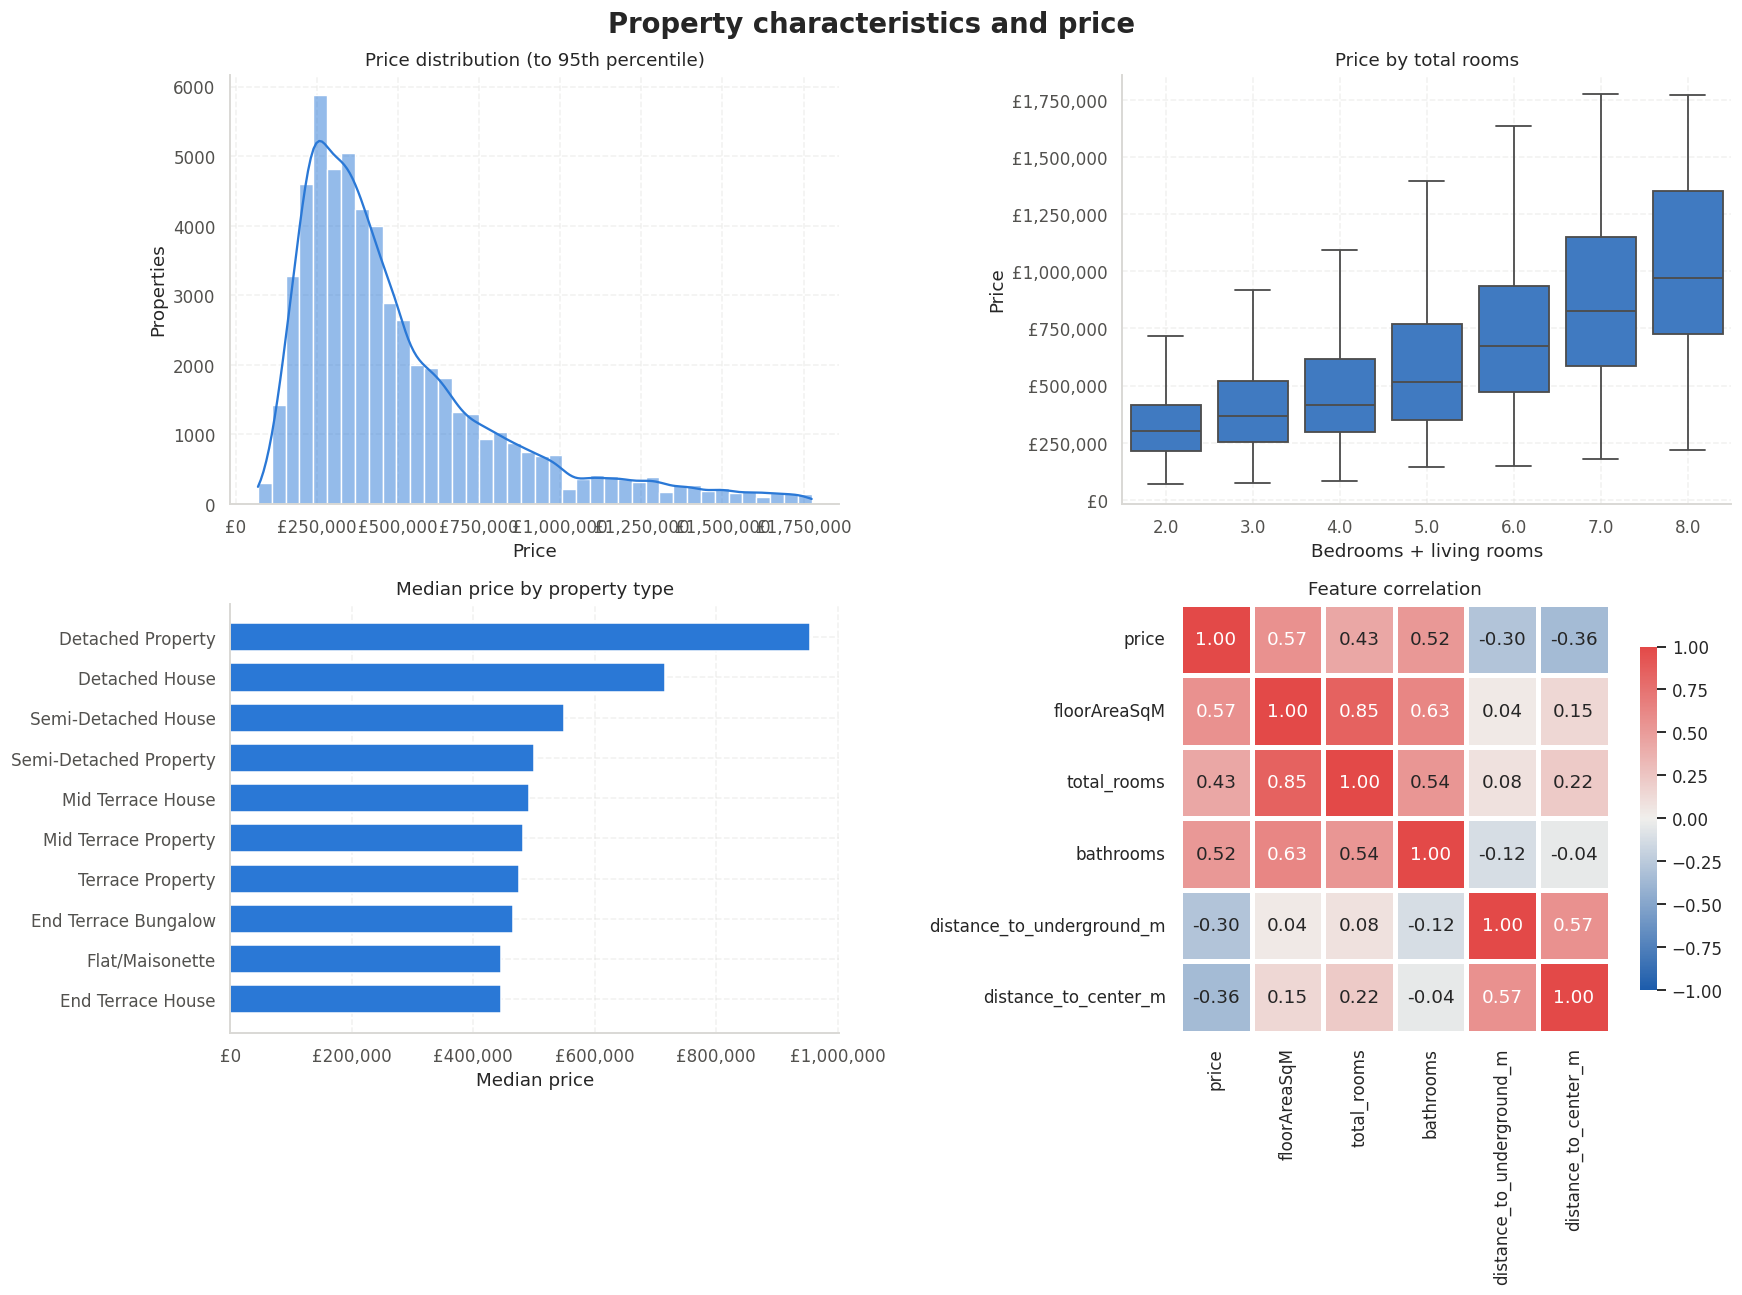

In [9]:
def plot_property_characteristics(df: pd.DataFrame, cfg: Config) -> None:
    """Physical drivers of price: distribution, scale, asset type, and inter-correlation."""
    vis = display_frame(df, cfg)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Property characteristics and price", fontsize=18, fontweight="bold")

    sns.histplot(vis["price"], bins=40, kde=True, ax=axes[0, 0], color=SERIES[0])
    axes[0, 0].set(title="Price distribution (to 95th percentile)",
                   xlabel="Price", ylabel="Properties")
    style_axis(axes[0, 0], currency_x=True)

    rooms = vis[vis["total_rooms"].between(1, 8)]
    sns.boxplot(data=rooms, x="total_rooms", y="price", ax=axes[0, 1],
                color=SERIES[0], showfliers=False, linewidth=1.2)
    axes[0, 1].set(title="Price by total rooms", xlabel="Bedrooms + living rooms", ylabel="Price")
    style_axis(axes[0, 1], currency_y=True)

    by_type = vis.groupby("propertyType")["price"].median().sort_values(ascending=False).head(10)
    axes[1, 0].barh(by_type.index[::-1], by_type.values[::-1], color=SERIES[0], height=0.7)
    axes[1, 0].set(title="Median price by property type", xlabel="Median price", ylabel="")
    style_axis(axes[1, 0], currency_x=True)

    cols = ["price", "floorAreaSqM", "total_rooms", "bathrooms",
            "distance_to_underground_m", "distance_to_center_m"]
    corr = vis[cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, center=0, vmin=-1, vmax=1,
                ax=axes[1, 1], square=True, linewidths=2, linecolor="white",
                cbar_kws={"shrink": 0.8})
    axes[1, 1].set_title("Feature correlation")

    plt.tight_layout()
    plt.show()


plot_property_characteristics(df_master, CONFIG)

### 8.1 Spatial, safety and macroeconomic drivers

Three external forces, each shown on its own scale.

The price-versus-interest-rate figure deliberately uses **two stacked panels sharing one x-axis
rather than a single chart with twin y-axes**. A dual-axis chart lets whoever draws it decide
where the two lines appear to cross by choosing the scales, which manufactures a visual
correlation that may not exist in the data. Stacked panels show the same co-movement without that
degree of freedom.

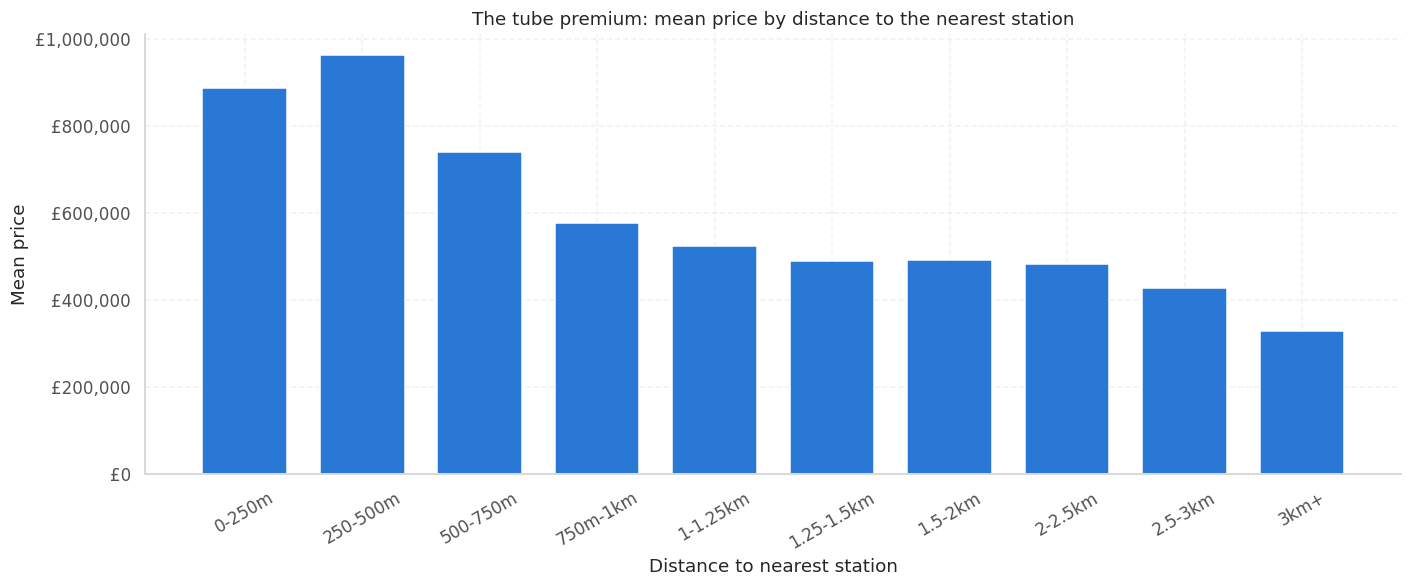

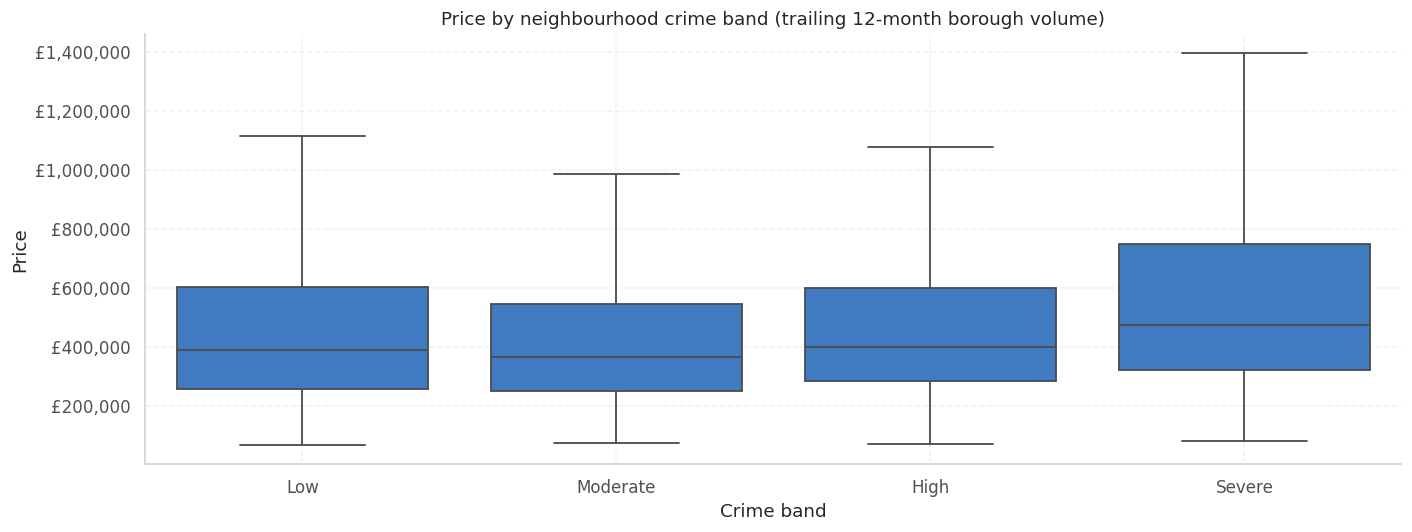

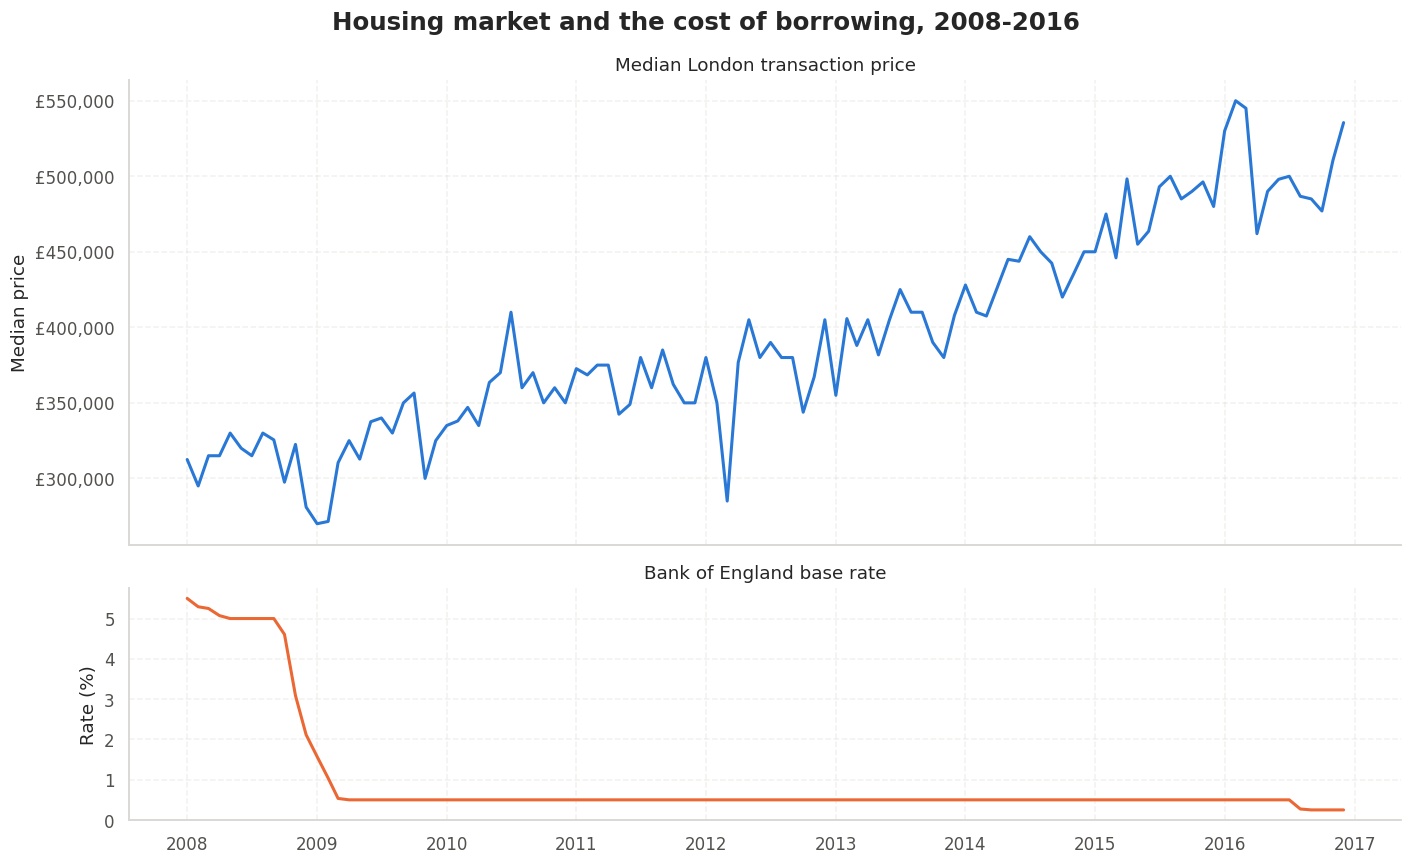

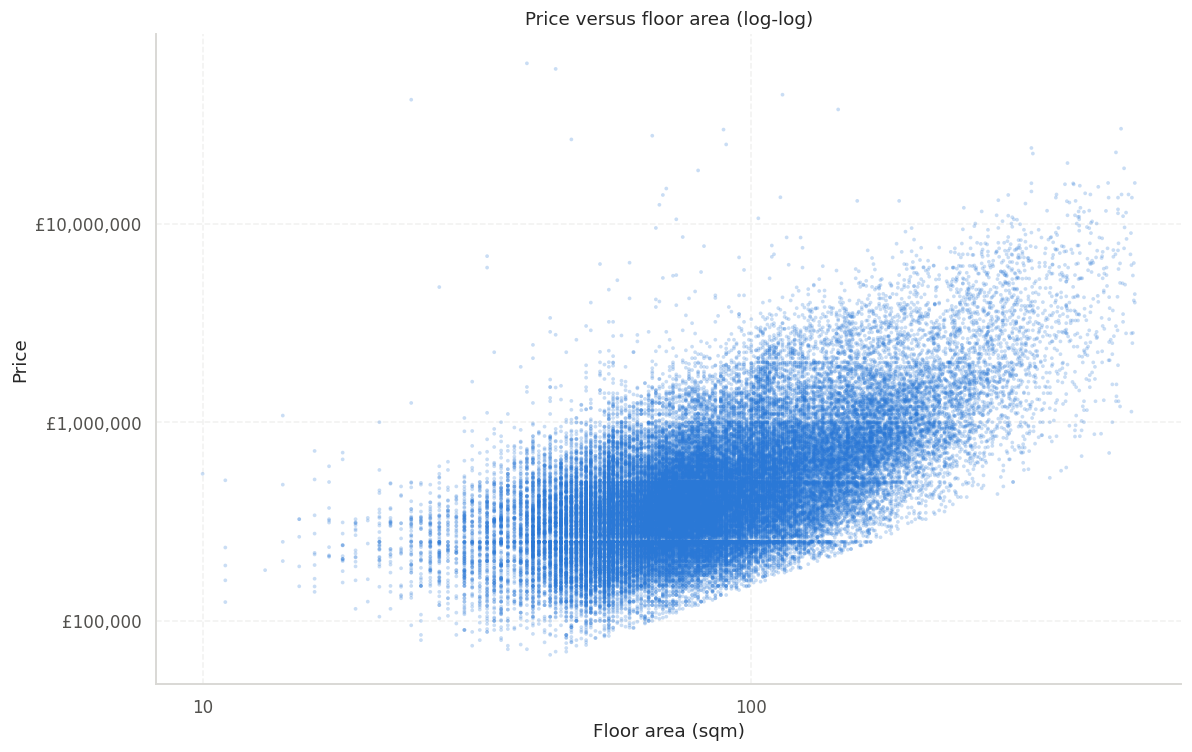

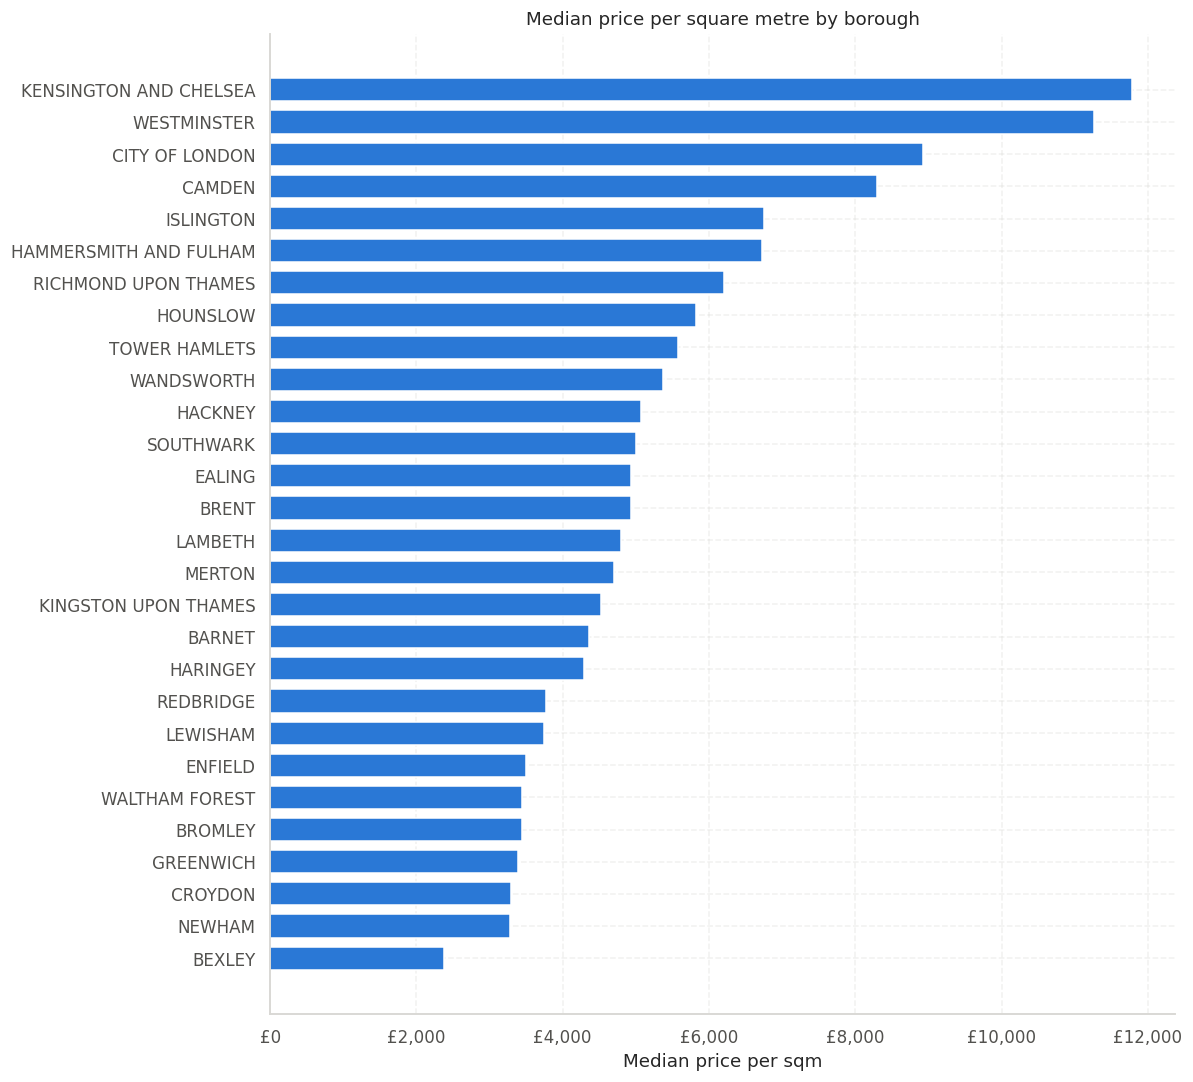

In [10]:
TUBE_BINS = [0, 250, 500, 750, 1000, 1250, 1500, 2000, 2500, 3000, np.inf]
TUBE_LABELS = ["0-250m", "250-500m", "500-750m", "750m-1km", "1-1.25km",
               "1.25-1.5km", "1.5-2km", "2-2.5km", "2.5-3km", "3km+"]


def plot_tube_premium(df: pd.DataFrame, cfg: Config) -> None:
    """Distance decay: how price falls as the walk to the nearest Underground station lengthens."""
    band = df[["distance_to_underground_m", "price"]].dropna().copy()
    band["distance_group"] = pd.cut(band["distance_to_underground_m"],
                                    bins=TUBE_BINS, labels=TUBE_LABELS)
    means = band.groupby("distance_group", observed=True)["price"].mean()

    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.bar(means.index.astype(str), means.values, color=SERIES[0], width=0.72)
    ax.set(title="The tube premium: mean price by distance to the nearest station",
           xlabel="Distance to nearest station", ylabel="Mean price")
    ax.tick_params(axis="x", rotation=30)
    style_axis(ax, currency_y=True)
    plt.tight_layout()
    plt.show()


def plot_crime_and_market(df: pd.DataFrame, cfg: Config) -> None:
    """Crime banding, plus price and base rate over time on shared time axis."""
    vis = display_frame(df, cfg)
    vis = vis.dropna(subset=["crime_volume_prev_12m"]).copy()
    vis["crime_level"] = pd.qcut(vis["crime_volume_prev_12m"], q=4,
                                 labels=["Low", "Moderate", "High", "Severe"])

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(data=vis, x="crime_level", y="price", ax=ax, color=SERIES[0],
                showfliers=False, linewidth=1.2)
    ax.set(title="Price by neighbourhood crime band (trailing 12-month borough volume)",
           xlabel="Crime band", ylabel="Price")
    style_axis(ax, currency_y=True)
    plt.tight_layout()
    plt.show()

    # Two panels sharing one x-axis -- never twin y-axes. See the note above.
    timeline = df.groupby("month_year").agg(
        price=("price", "median"), interest_rate=("interest_rate", "mean")
    ).reset_index()

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )
    ax_top.plot(timeline["month_year"], timeline["price"], color=SERIES[0], linewidth=2)
    ax_top.set(title="Median London transaction price", ylabel="Median price")
    style_axis(ax_top, currency_y=True)

    ax_bot.plot(timeline["month_year"], timeline["interest_rate"], color=SERIES[1], linewidth=2)
    ax_bot.set(title="Bank of England base rate", ylabel="Rate (%)", xlabel="")
    style_axis(ax_bot)

    fig.suptitle("Housing market and the cost of borrowing, 2008-2016",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_price_vs_area(df: pd.DataFrame, cfg: Config) -> None:
    """Log-log scale: where 'mega-properties' depart from the standard market trend."""
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(df["floorAreaSqM"], df["price"], s=6, alpha=0.25,
               color=SERIES[0], edgecolors="none")
    ax.set(xscale="log", yscale="log", xlabel="Floor area (sqm)", ylabel="Price",
           title="Price versus floor area (log-log)")
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    style_axis(ax, currency_y=True)
    plt.tight_layout()
    plt.show()


def plot_price_per_sqm_by_borough(df: pd.DataFrame, cfg: Config) -> None:
    """Unit land value -- strips out the size effect that dominates headline price."""
    per_sqm = df.groupby("borough")["price_per_sqm"].median().sort_values()
    fig, ax = plt.subplots(figsize=(11, 10))
    ax.barh(per_sqm.index, per_sqm.values, color=SERIES[0], height=0.72)
    ax.set(title="Median price per square metre by borough", xlabel="Median price per sqm",
           ylabel="")
    style_axis(ax, currency_x=True)
    plt.tight_layout()
    plt.show()


plot_tube_premium(df_master, CONFIG)
plot_crime_and_market(df_master, CONFIG)
plot_price_vs_area(df_master, CONFIG)
plot_price_per_sqm_by_borough(df_master, CONFIG)

---
## 9. Temporal and market feature engineering

This is where most of the leakage risk in a property model lives, so every feature here is built
to answer one question: *would a buyer standing at the transaction date have known this?*

| Feature | Construction | Why it cannot leak |
|---|---|---|
| `days_since_start` | days elapsed since the first transaction | derived from the row's own date |
| `month_sin`, `month_cos` | cyclic encoding of calendar month | December and January end up adjacent, as they are in reality |
| `market_median_rolling_3m` / `_12m` | market-wide monthly median, `.shift(1)` then rolled | the shift drops the current month before the window opens |
| `lagged_borough_median_sqm` | borough £/sqm median, stamped onto the *following* month | a month's own price never informs its own prediction |
| `avg_room_size` | floor area ÷ total rooms | a within-row ratio |

`avg_room_size` needs care: `total_rooms` can be zero, which yields ±∞ rather than NaN. Those are
converted to NaN explicitly and then **left as NaN**. Filling them with the column median here
would leak: this function runs on the whole table, before the split, so that median would be
computed over validation, calibration and test rows and then baked into a training feature. It is a
small leak but a real one. Leaving NaN defers the
imputation to each model, where it happens inside a pipeline fitted on the training split alone.

In [11]:
def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Calendar position and dwelling-scale ratios -- every value derived from its own row."""
    out = df.sort_values("date").reset_index(drop=True)
    out["month_year_period"] = out["date"].dt.to_period("M")
    out["days_since_start"] = (out["date"] - out["date"].min()).dt.days

    month = out["date"].dt.month
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)

    # total_rooms == 0 produces +/-inf rather than NaN, so convert explicitly.
    out["avg_room_size"] = (out["floorAreaSqM"] / out["total_rooms"]).replace(
        [np.inf, -np.inf], np.nan
    )
    # Deliberately NOT median-filled. This function runs on the whole table, before the split,
    # so a median here would be computed over validation, calibration and test rows and then
    # baked into a training feature -- textbook leakage. Left as NaN for the same reason crime
    # is (section 7): the GBDTs handle it natively and Ridge imputes inside a pipeline fitted
    # on the training split alone.
    return out


def add_market_features(df: pd.DataFrame) -> pd.DataFrame:
    """Market momentum and localised price level -- both strictly lagged."""
    out = df.copy()

    monthly = (
        out.groupby("month_year_period")["price"].median().sort_index().to_frame("monthly_median")
    )
    # .shift(1) removes the current month *before* the window opens, so a month's own
    # median can never appear among its own predictors.
    shifted = monthly["monthly_median"].shift(1)
    monthly["market_median_rolling_3m"] = shifted.rolling(3, min_periods=1).median()
    monthly["market_median_rolling_12m"] = shifted.rolling(12, min_periods=1).median()

    borough_sqm = (
        out.groupby(["month_year_period", "borough"], observed=True)["price_per_sqm"]
        .median()
        .reset_index()
        .rename(columns={"price_per_sqm": "lagged_borough_median_sqm"})
    )
    # Stamp each month's borough level onto the FOLLOWING month.
    borough_sqm["month_year_period"] = borough_sqm["month_year_period"] + 1

    out = out.merge(
        monthly[["market_median_rolling_3m", "market_median_rolling_12m"]],
        on="month_year_period", how="left",
    )
    out = out.merge(borough_sqm, on=["month_year_period", "borough"], how="left")
    return out


FEATURES = [
    "floorAreaSqM", "total_rooms", "avg_room_size", "bathrooms",
    "distance_to_underground_m", "distance_to_transit_m", "station_zone",
    "distance_to_center_m", "latitude", "longitude",
    "crime_volume", "crime_volume_prev_12m", "interest_rate",
    "propertyType", "tenure", "borough", "outcode", "currentEnergyRating",
    "days_since_start", "month_sin", "month_cos",
    "market_median_rolling_3m", "market_median_rolling_12m", "lagged_borough_median_sqm",
]
CATEGORICAL_FEATURES = ["propertyType", "tenure", "borough", "outcode", "currentEnergyRating"]

# Feature groups for the ablation study in section 14.5.
FEATURE_GROUPS = {
    "crime": ["crime_volume", "crime_volume_prev_12m"],
    "transport": ["distance_to_underground_m", "distance_to_transit_m", "station_zone"],
    "macro": ["interest_rate"],
    "market lags": ["market_median_rolling_3m", "market_median_rolling_12m",
                    "lagged_borough_median_sqm"],
}
NUMERIC_FEATURES = [f for f in FEATURES if f not in CATEGORICAL_FEATURES]
TARGET = "price"

df_model = add_market_features(add_temporal_features(df_master))
df_model = df_model.dropna(subset=[TARGET, "date"]).reset_index(drop=True)

print(f"Modelling table: {df_model.shape}")
print(f"Features: {len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical")
missing = df_model[FEATURES].isna().mean().sort_values(ascending=False)
print("\nMissing-value rate by feature (top 6):")
print(missing.head(6).to_string())

Modelling table: (59946, 33)
Features: 19 numeric + 5 categorical

Missing-value rate by feature (top 6):
currentEnergyRating      0.252327
bathrooms                0.159610
avg_room_size            0.124946
total_rooms              0.124946
crime_volume_prev_12m    0.075501
tenure                   0.012144


---
## 10. Chronological partitioning and encoding

**The split is by time, not at random.** A random split would let the model learn from June 2016
to predict January 2016, which is not a situation that ever occurs in production. Sorting by date
and cutting **60 / 15 / 10 / 15** into train / validation / calibration / test reproduces the real
task: train on the past, forecast the future.

**Why calibration gets its own slice.** A single validation set cannot serve three roles at once —
early stopping, model selection, and calibrating the conformal safety bound — without the "90 %
guarantee" in section 15 being partly calibrated on data the model was already tuned against. That
is circular, so calibration gets a dedicated slice that nothing else touches. The ordering of the
two middle slices was tested both ways; validation-then-calibration is kept because it produces
smaller validation-to-test drift for the tree models, at the cost of a little exchangeability on
the calibration split.

### One evaluation universe, three training variants

Comparing a "raw", a "capped" and a "cleaned" model is only meaningful if all three are scored on
the same rows; letting the evaluation set vary alongside the training set compares models and test
sets at once. Here the evaluation universe is fixed (validation and test rows under the £4 M cap,
the standard market the product actually targets) and only the **training** data varies:

| Variant | Training rows |
|---|---|
| `raw` | every transaction, including £4 M+ |
| `capped` | transactions at or below the cap |
| `cleaned` | capped, minus multivariate anomalies |

**Anomalies are removed from training only.** Fitting `IsolationForest` on the whole dataset and
dropping the flagged rows everywhere would delete the hard cases from validation and test as well —
marking your own exam after removing the difficult questions. A production model does not get to
refuse the awkward listings. Here the forest is fitted on the training slice alone and filters only
that.

### Encoding

Two representations, both fitted on training data only:

* **Native categoricals** (`category` dtype) for XGBoost, with the level set pinned from the
  training split so a category means the same integer code everywhere. CatBoost gets the raw
  strings via `cat_features`. These columns must never be coerced with
  `pd.to_numeric(..., errors='coerce')`, which turns all four **entirely NaN** and leaves the
  CatBoost models and every Mixture-of-Experts router training on dead columns.
* **Smoothed target encoding** for the models that require numeric input (the routers). The
  smoothing pulls low-frequency categories toward the global mean so a borough with three sales
  does not get a confident price estimate.

In [12]:
class SmoothedTargetEncoder:
    """Mean-target encoding with shrinkage toward the global mean. Fitted on training data only."""

    def __init__(self, columns: Sequence[str], smoothing: int = 10):
        self.columns = list(columns)
        self.smoothing = smoothing
        self.mappings_: dict[str, pd.Series] = {}
        self.global_mean_: float = np.nan

    def fit(self, X: pd.DataFrame, y: pd.Series) -> SmoothedTargetEncoder:
        self.global_mean_ = float(y.mean())
        frame = X[self.columns].astype(object).assign(_target=np.asarray(y, dtype=float))
        for col in self.columns:
            stats = frame.groupby(col, observed=True)["_target"].agg(["count", "mean"])
            self.mappings_[col] = (
                (stats["count"] * stats["mean"] + self.smoothing * self.global_mean_)
                / (stats["count"] + self.smoothing)
            )
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        out = X.copy()
        for col in self.columns:
            out[col] = out[col].astype(object).map(self.mappings_[col]).astype(float)
            out[col] = out[col].fillna(self.global_mean_)  # categories unseen in training
        return out.apply(pd.to_numeric, errors="coerce")


@dataclass(frozen=True)
class Splits:
    """Four chronologically ordered frames plus fitted encoders.

    train fits the model. val drives early stopping and model selection. calib is touched by
    nothing else -- it exists purely so conformal calibration never runs on data the model was
    tuned against. test is never used to fit or choose anything; it is read only to report
    performance, in sections 14, 14.1 and 15.
    """

    train: pd.DataFrame
    val: pd.DataFrame
    calib: pd.DataFrame
    test: pd.DataFrame
    category_dtypes: dict
    encoder: SmoothedTargetEncoder

    def features(self, part: pd.DataFrame) -> pd.DataFrame:
        """Feature matrix with training-pinned categorical levels."""
        X = part[FEATURES].copy()
        for col, dtype in self.category_dtypes.items():
            X[col] = X[col].astype(dtype)
        return X

    def target(self, part: pd.DataFrame) -> pd.Series:
        return part[TARGET]


def chronological_split(df: pd.DataFrame, cfg: Config) -> Splits:
    """Split by time into four slices, then fit every encoder on the training slice alone."""
    ordered = df.sort_values("date").reset_index(drop=True)
    n = len(ordered)
    train_end = int(n * cfg.train_frac)
    val_end = train_end + int(n * cfg.val_frac)
    calib_end = val_end + int(n * cfg.calib_frac)

    train = ordered.iloc[:train_end]
    val = ordered.iloc[train_end:val_end]
    calib = ordered.iloc[val_end:calib_end]
    test = ordered.iloc[calib_end:]

    category_dtypes = {
        col: pd.CategoricalDtype(categories=sorted(train[col].dropna().astype(str).unique()))
        for col in CATEGORICAL_FEATURES
    }
    for part in (train, val, calib, test):
        for col in CATEGORICAL_FEATURES:
            part.loc[:, col] = part[col].astype(str)

    encoder = SmoothedTargetEncoder(CATEGORICAL_FEATURES, cfg.target_encoding_smoothing)
    encoder.fit(train[FEATURES], train[TARGET])

    splits = Splits(train, val, calib, test, category_dtypes, encoder)
    for name, part in (("train", train), ("val", val), ("calib", calib), ("test", test)):
        print(f"{name:<6}{len(part):>7,} rows   {part['date'].min():%Y-%m-%d} -> "
              f"{part['date'].max():%Y-%m-%d}")
    return splits


SPLITS = chronological_split(df_model, CONFIG)

# One fixed evaluation universe for every model: the standard market, under the cap.
VAL_EVAL = SPLITS.val[SPLITS.val[TARGET] <= CONFIG.price_cap]
CALIB_EVAL = SPLITS.calib[SPLITS.calib[TARGET] <= CONFIG.price_cap]
TEST_EVAL = SPLITS.test[SPLITS.test[TARGET] <= CONFIG.price_cap]
print(f"\nEvaluation universe (price <= \N{POUND SIGN}{CONFIG.price_cap:,.0f}): "
      f"{len(VAL_EVAL):,} validation, {len(CALIB_EVAL):,} calibration, "
      f"{len(TEST_EVAL):,} test rows")

train  35,967 rows   2008-01-01 -> 2014-04-17
val     8,991 rows   2014-04-17 -> 2015-04-30
calib   5,994 rows   2015-04-30 -> 2015-12-17
test    8,994 rows   2015-12-17 -> 2016-12-31

Evaluation universe (price <= £4,000,000): 8,840 validation, 5,916 calibration, 8,859 test rows


In [13]:
def training_variants(splits: Splits, cfg: Config) -> dict[str, pd.DataFrame]:
    """Three training sets over one fixed evaluation universe."""
    raw = splits.train
    capped = raw[raw[TARGET] <= cfg.price_cap]

    # IsolationForest is fitted on TRAINING rows only and filters TRAINING rows only.
    anomaly_cols = ["floorAreaSqM", "total_rooms", TARGET,
                    "distance_to_underground_m", "lagged_borough_median_sqm"]
    fit_frame = capped[anomaly_cols].dropna()
    forest = IsolationForest(
        n_estimators=100, contamination=cfg.iso_contamination, random_state=cfg.seed, n_jobs=-1
    ).fit(fit_frame)

    # Drop ONLY the rows the forest actually flags. An earlier version kept just the rows that
    # survived `fit_frame`, which silently also deleted every row with a NaN in any anomaly
    # column -- including the whole first month, where lagged_borough_median_sqm does not exist
    # yet. That made "cleaned" mean "anomalies removed AND the front of the window removed", so
    # capped-vs-cleaned was never a clean comparison of anomaly removal alone.
    flagged = fit_frame.index[forest.predict(fit_frame) == -1]
    cleaned = capped.drop(index=flagged)

    variants = {"raw": raw, "capped": capped, "cleaned": cleaned}
    for name, frame in variants.items():
        print(f"{name:<9}{len(frame):>7,} training rows")
    print(f"\nIsolationForest scored {len(fit_frame):,} of {len(capped):,} capped training rows "
          f"({len(capped) - len(fit_frame):,} skipped for missing values, kept as-is) and flagged "
          f"{len(flagged):,} anomalies ({cfg.iso_contamination:.0%} target rate); "
          f"validation and test are untouched.")
    return variants


VARIANTS = training_variants(SPLITS, CONFIG)

raw       35,967 training rows
capped    35,693 training rows
cleaned   35,075 training rows

IsolationForest scored 30,853 of 35,693 capped training rows (4,840 skipped for missing values, kept as-is) and flagged 618 anomalies (2% target rate); validation and test are untouched.


---
## 11. Metrics

One metric function, used by every model. Near-identical variants defined across several cells are
how a leaderboard ends up silently mixing two different spellings of the same metric, and with them
two different numbers.

**MdAPE (median absolute percentage error) is the headline metric.** MAE is reported in pounds and
is easy to explain, but it is dominated by the expensive tail: a 10 % miss on a £3 M house
contributes thirty times more than a 10 % miss on a £100 k flat, even though both are equally
wrong in the only sense the buyer cares about. The median of the percentage errors is robust to
that tail and answers the practical question — *what does a typical valuation get wrong by?*

In [14]:
def regression_metrics(y_true, y_pred) -> dict[str, float]:
    """The single metric implementation used everywhere in this notebook."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs((y_true - y_pred) / y_true)
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MdAPE": float(np.median(ape) * 100),
        "MAPE": float(np.mean(ape) * 100),
        "within_25pct": float((ape <= 0.25).mean() * 100),
    }


@dataclass
class ModelBundle:
    """A trained model behind one uniform predict() -- the key to comparing like with like."""

    name: str
    trained_on: str
    predict: Callable[[pd.DataFrame], np.ndarray]
    artefacts: dict = field(default_factory=dict)


class ResultsRegistry:
    """Collects every evaluation so the leaderboard is generated, never hand-typed."""

    def __init__(self) -> None:
        self.rows: list[dict] = []

    def add(self, bundle: ModelBundle, split: str, metrics: dict[str, float]) -> dict[str, float]:
        self.rows.append({"Model": bundle.name, "Trained on": bundle.trained_on,
                          "Split": split, **metrics})
        return metrics

    def frame(self, split: str | None = None) -> pd.DataFrame:
        df = pd.DataFrame(self.rows)
        if split is not None:
            df = df[df["Split"] == split]
        return df.sort_values("MdAPE").reset_index(drop=True)


def evaluate(bundle: ModelBundle, part: pd.DataFrame, split: str,
             registry: ResultsRegistry, splits: Splits = None) -> dict[str, float]:
    """Score a bundle on an evaluation frame and record the result."""
    splits = splits or SPLITS
    metrics = regression_metrics(splits.target(part), bundle.predict(splits.features(part)))
    registry.add(bundle, split, metrics)
    print(f"{bundle.name:<34}{split:<6}"
          f"MdAPE {metrics['MdAPE']:6.2f}%   MAE \N{POUND SIGN}{metrics['MAE']:>10,.0f}   "
          f"R2 {metrics['R2']:6.3f}")
    return metrics


RESULTS = ResultsRegistry()

---
## 12. Models

Every trainer returns a `ModelBundle` exposing the same `predict(X)` signature. That uniformity is
not cosmetic — it is what lets the leaderboard, the test evaluation and the conformal calibration
below all run through one code path. It also closes off a whole class of error: a conformal step
that reaches for a concrete estimator such as `expert_0.predict(X_test)` computes its guarantee
from whatever that name happens to point at, which need not be the model under evaluation, and
fails silently when it is not.

**All targets are modelled in log space** (`log1p` in, `expm1` out). Property prices are strongly
right-skewed; training on the log makes the loss approximately proportional rather than absolute,
which is the same reason MdAPE is the headline metric.

| Model | Role |
|---|---|
| Ridge | linear baseline — how far do straight-line relationships get you? |
| XGBoost | the workhorse gradient-boosted tree |
| CatBoost | alternative booster with native categorical handling |
| XGBoost / CatBoost detrended | same trees, target is `log(price / market level)` instead of `log(price)` — see 12.1 |
| Luxury MoE | router splits standard from luxury, one expert each, soft-weighted |
| Error-driven MoE | three diverse experts, router learns which wins per property |
| 3-seed average | **the honest control** for the error-driven MoE (see below) |

The 3-seed average is the control that makes the MoE result interpretable. The error-driven MoE
trains three experts that differ only by random seed, then routes between them.
Averaging those same three experts costs nothing extra and is what the routing must beat to
justify its complexity — without that control, a "Mixture of Experts" that merely beats a single
model has proved only that ensembling works.

**Both MoE architectures are trained on the detrended recipe as well as the plain one.** Judging an
MoE only on plain `log(price)` -- the target that costs the single trees their accuracy -- would
test routing against a handicapped baseline and credit it for a fix it did not make. Training both
makes the comparison the informative one: does routing or averaging add anything *on top of* the
best single model, rather than on top of a target that is already mis-levelled. See 14.4.

In [15]:
def _as_string_frame(X: pd.DataFrame) -> pd.DataFrame:
    """Categorical columns as plain strings -- module level so the pipeline stays picklable."""
    return X.astype(str)


def _catboost_frame(X: pd.DataFrame) -> pd.DataFrame:
    """CatBoost wants raw strings in cat_features, never numeric codes."""
    out = X.copy()
    for col in CATEGORICAL_FEATURES:
        out[col] = out[col].astype(str).fillna("MISSING")
    return out


def train_ridge(train_df: pd.DataFrame, splits: Splits, cfg: Config, variant: str) -> ModelBundle:
    """Regularised linear baseline: median-imputed + scaled numerics, one-hot categoricals."""
    numeric_tf = Pipeline([("impute", SimpleImputer(strategy="median")),
                           ("scale", StandardScaler())])
    categorical_tf = Pipeline([
        ("to_str", FunctionTransformer(_as_string_frame, feature_names_out="one-to-one")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    pipeline = Pipeline([
        ("prep", ColumnTransformer([("num", numeric_tf, NUMERIC_FEATURES),
                                    ("cat", categorical_tf, CATEGORICAL_FEATURES)])),
        ("model", TransformedTargetRegressor(regressor=Ridge(alpha=1.0),
                                             func=np.log1p, inverse_func=np.expm1)),
    ])
    pipeline.fit(splits.features(train_df), splits.target(train_df))
    return ModelBundle("Ridge (baseline)", variant, lambda X: pipeline.predict(X),
                       {"pipeline": pipeline})


def train_xgboost(train_df: pd.DataFrame, val_df: pd.DataFrame, splits: Splits,
                  cfg: Config, variant: str) -> ModelBundle:
    """Gradient-boosted trees with native categorical support and early stopping."""
    model = xgb.XGBRegressor(
        n_estimators=cfg.n_estimators, max_depth=8, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, enable_categorical=True, tree_method="hist",
        early_stopping_rounds=50, random_state=cfg.seed, n_jobs=-1,
    )
    model.fit(
        splits.features(train_df), np.log1p(splits.target(train_df)),
        eval_set=[(splits.features(val_df), np.log1p(splits.target(val_df)))], verbose=False,
    )
    return ModelBundle(f"XGBoost ({variant})", variant,
                       lambda X: np.expm1(model.predict(X)), {"model": model})


def train_catboost(train_df: pd.DataFrame, val_df: pd.DataFrame, splits: Splits,
                   cfg: Config, variant: str) -> ModelBundle:
    """CatBoost with genuine categorical features -- the original passed it four all-NaN columns."""
    model = CatBoostRegressor(
        iterations=cfg.catboost_iterations, learning_rate=0.05, depth=8, l2_leaf_reg=3,
        loss_function="MAE", eval_metric="MAE", random_seed=cfg.seed, verbose=False,
    )
    model.fit(
        _catboost_frame(splits.features(train_df)), np.log1p(splits.target(train_df)),
        eval_set=(_catboost_frame(splits.features(val_df)), np.log1p(splits.target(val_df))),
        cat_features=CATEGORICAL_FEATURES, use_best_model=True, early_stopping_rounds=50,
    )
    return ModelBundle(f"CatBoost ({variant})", variant,
                       lambda X: np.expm1(model.predict(_catboost_frame(X))), {"model": model})

### 12.1 Detrending the target: a fix, not just a diagnosis

Gradient-boosted trees are normally the stronger choice on tabular data of this shape, so a plain
Ridge regression beating them on test by five points of MdAPE or more reads as a symptom rather
than a verdict on the architecture. Detrending — predicting the ratio to the market level instead
of the raw price — addresses the mechanism behind that symptom rather than the symptom itself.

The plain XGBoost/CatBoost models above train on `log1p(price)`. A tree's prediction is a
constant per leaf, so once a test-time value of a trending feature (`days_since_start`,
`market_median_rolling_3m`) exceeds anything seen in training, every such row lands in the same
boundary leaf and the model flat-lines at the last price level it learned -- it cannot
extrapolate a rising market. Ridge suffers less, because it multiplies by a coefficient instead of
splitting and so at least projects the trend forward -- though section 12.2 shows it is not immune
either, only less exposed.

That is a testable hypothesis, not a guess: the plain trees under-predict by a large, positive
mean residual — a one-directional level error, not noise. Section 12.2 measures that bias on the
**validation** set, which is the version of the evidence this notebook is entitled to act on. The
same effect measures +£128,318 on test; section 12.2 exists so that the conclusion does not rest on
the held-out set, and section 18 records the order in which the two were actually observed.

**The fix removes the need to extrapolate at all.** Instead of predicting price, predict the
*ratio* of price to the lagged whole-market median (`market_median_rolling_3m`, already a
leakage-safe feature computed in section 9):

$$y = \log\!\left(\frac{\text{price}}{\text{market level}}\right)$$

"How much is this property worth relative to where the market already is" is close to
stationary across time, even while the market itself trends -- so a tree only has to
*interpolate* within the range of ratios it saw in training, never extrapolate beyond it. The
market level is multiplied back onto the prediction at inference time.

The second change is the training objective: XGBoost defaults to squared error with no
`objective` set, which does not match MdAPE (a median of relative errors). Setting
`objective="reg:absoluteerror"` on log-ratio space optimises something close to the actual
metric. CatBoost already trains with an MAE loss, so only the detrending applies there --
isolating which of the two changes is doing the work.

These are real competitors, not a side experiment: they are registered in `train_all()` like
every other model, so whichever one wins on validation becomes `BEST` and flows through test
evaluation, the repeat-property diagnostic and conformal calibration exactly like any other
model would.

One caveat worth stating plainly rather than leaving implied: selecting *among* the candidates on
validation is clean, but the detrended family entered the candidate pool at all because of an
observation first made on test. Competing fairly afterwards does not retroactively make the
candidate pool test-blind. Section 12.2 is the repair — it shows the same diagnosis is reachable
from validation — and section 18 records the history.

**Two deflators, compared head to head rather than assumed.** `market_median_rolling_3m` is one
number per calendar month, shared by every property regardless of size or borough -- it removes
the market-wide time trend and nothing else. A finer alternative is `lagged_borough_median_sqm x
floorAreaSqM`: a size- and location-scaled deflator, personalised per row. It is *not* built by
bucketing on a coarse category like bedroom count, deliberately -- slicing a 3-month window by
bedrooms x borough x property type would leave many cells with only a handful of sales, and a
noisy deflator injects noise directly into every label it divides. Floor area is continuous, so
`lagged_borough_median_sqm x floorAreaSqM` scales smoothly to the exact property instead of
falling into a sparse bucket, while borough alone (33 categories, thousands of sales each) stays
statistically stable month to month. Both deflators train an XGBoost and a CatBoost model each,
so this doubles as a test of whether finer-grained detrending is worth its added complexity.

In [16]:
def fit_market_deflator(train_df: pd.DataFrame) -> float:
    """Training-only fallback for the handful of rows too early to have a 3-month rolling window."""
    return float(train_df["market_median_rolling_3m"].median())


def market_level(X: pd.DataFrame, deflator: float) -> np.ndarray:
    """Lagged whole-market median price -- a calendar-time deflator, the same number for
    every property sold in a given month regardless of its size or location."""
    level = X["market_median_rolling_3m"].fillna(X["market_median_rolling_12m"])
    return level.fillna(deflator).to_numpy()


def fit_borough_deflator(train_df: pd.DataFrame) -> tuple[float, float]:
    """Training-only fallbacks: the market-wide level (missing borough data) and the median
    floor area (missing floorAreaSqM)."""
    return (
        float(train_df["market_median_rolling_3m"].median()),
        float(train_df["floorAreaSqM"].median()),
    )


def borough_level(X: pd.DataFrame, deflator: tuple[float, float]) -> np.ndarray:
    """Lagged borough L/sqm x this property's own floor area -- a size- and location-scaled
    deflator, personalised per row rather than one number per month. Falls back to the
    market-wide level (fit_market_deflator's constant) wherever borough or area data is
    missing, rather than bucketing on a coarse category like bedroom count: bucketing by
    bedrooms x borough x property type would leave many 3-month cells with only a handful of
    sales, and a noisy deflator injects noise directly into every label it is divided into.
    """
    market_fallback, area_fallback = deflator
    area = X["floorAreaSqM"].fillna(area_fallback)
    level = X["lagged_borough_median_sqm"] * area
    market_wide = X["market_median_rolling_3m"].fillna(X["market_median_rolling_12m"])
    market_wide = market_wide.fillna(market_fallback)
    return level.fillna(market_wide).to_numpy()


# Two deflator strategies, compared head-to-head in the leaderboard rather than assumed.
DEFLATORS = {
    "market": (fit_market_deflator, market_level),
    "borough": (fit_borough_deflator, borough_level),
}


def detrend(y: pd.Series, level: np.ndarray) -> np.ndarray:
    """log(price / level): a ratio a tree can interpolate instead of extrapolating price."""
    return np.log(y.to_numpy(dtype=float) / level)


def retrend(y_log_ratio: np.ndarray, level: np.ndarray) -> np.ndarray:
    """Invert detrend() -- multiply the predicted ratio back onto the deflator level."""
    return np.exp(y_log_ratio) * level


def train_xgboost_detrended(train_df: pd.DataFrame, val_df: pd.DataFrame, splits: Splits,
                            cfg: Config, variant: str, deflator_kind: str = "market") -> ModelBundle:
    """XGBoost on a detrended, stationary target with an MAE objective aligned to MdAPE."""
    fit_deflator, level_fn = DEFLATORS[deflator_kind]
    deflator = fit_deflator(train_df)
    X_train, X_val = splits.features(train_df), splits.features(val_df)
    y_train = detrend(splits.target(train_df), level_fn(X_train, deflator))
    y_val = detrend(splits.target(val_df), level_fn(X_val, deflator))

    model = xgb.XGBRegressor(
        n_estimators=cfg.n_estimators, max_depth=8, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, enable_categorical=True, tree_method="hist",
        objective="reg:absoluteerror", early_stopping_rounds=50, random_state=cfg.seed, n_jobs=-1,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    def predict(X: pd.DataFrame) -> np.ndarray:
        return retrend(model.predict(X), level_fn(X, deflator))

    return ModelBundle(f"XGBoost detrended-{deflator_kind} ({variant})", variant, predict,
                       {"model": model})


def train_catboost_detrended(train_df: pd.DataFrame, val_df: pd.DataFrame, splits: Splits,
                             cfg: Config, variant: str, deflator_kind: str = "market") -> ModelBundle:
    """CatBoost on the same detrended target -- isolates detrending's effect from the loss's,
    since CatBoost already trains with an MAE loss."""
    fit_deflator, level_fn = DEFLATORS[deflator_kind]
    deflator = fit_deflator(train_df)
    X_train, X_val = splits.features(train_df), splits.features(val_df)
    y_train = detrend(splits.target(train_df), level_fn(X_train, deflator))
    y_val = detrend(splits.target(val_df), level_fn(X_val, deflator))

    model = CatBoostRegressor(
        iterations=cfg.catboost_iterations, learning_rate=0.05, depth=8, l2_leaf_reg=3,
        loss_function="MAE", eval_metric="MAE", random_seed=cfg.seed, verbose=False,
    )
    model.fit(
        _catboost_frame(X_train), y_train, eval_set=(_catboost_frame(X_val), y_val),
        cat_features=CATEGORICAL_FEATURES, use_best_model=True, early_stopping_rounds=50,
    )

    def predict(X: pd.DataFrame) -> np.ndarray:
        return retrend(model.predict(_catboost_frame(X)), level_fn(X, deflator))

    return ModelBundle(f"CatBoost detrended-{deflator_kind} ({variant})", variant, predict,
                       {"model": model})

In [17]:
def _make_expert(backend: str, seed: int, cfg: Config, target_transform: str = "log"):
    if backend == "xgboost":
        # Match the winning single model's recipe when experts train on a detrended target,
        # so "does routing help" is the only variable, not "does routing help AND get a
        # better-aligned loss for free".
        objective = "reg:absoluteerror" if target_transform == "detrend-market" else "reg:squarederror"
        return xgb.XGBRegressor(
            n_estimators=cfg.n_expert_estimators, max_depth=7, learning_rate=0.03,
            subsample=0.7, colsample_bytree=0.8, enable_categorical=True, tree_method="hist",
            objective=objective, random_state=seed, n_jobs=-1,
        )
    return CatBoostRegressor(
        iterations=cfg.n_expert_estimators, depth=7, learning_rate=0.05, loss_function="MAE",
        bootstrap_type="Bernoulli", subsample=0.7, random_seed=seed, verbose=False,
    )


def _fit_expert(model, backend: str, X: pd.DataFrame, y_log: np.ndarray):
    if backend == "catboost":
        model.fit(_catboost_frame(X), y_log, cat_features=CATEGORICAL_FEATURES)
    else:
        model.fit(X, y_log)
    return model


def _predict_log(model, backend: str, X: pd.DataFrame) -> np.ndarray:
    return model.predict(_catboost_frame(X) if backend == "catboost" else X)


def _router_transform(splits: Splits, imputer: SimpleImputer, X: pd.DataFrame) -> np.ndarray:
    """Routers need dense numerics: target-encode the categoricals, then impute."""
    return imputer.transform(splits.encoder.transform(X))


def train_moe_luxury(train_df: pd.DataFrame, splits: Splits, cfg: Config,
                     variant: str, target_transform: str = "log") -> ModelBundle:
    """Router separates standard from luxury stock; one expert each, blended by probability.

    `target_transform="detrend-market"` trains both experts on section 12.1's fix (the winning
    single model's recipe) instead of plain log1p(price), so this MoE competes fairly against
    the best single model rather than against a version of itself handicapped by the extrapolation
    bug the single model no longer has.
    """
    X_train, y_train = splits.features(train_df), splits.target(train_df)
    is_luxury = (y_train >= cfg.luxury_threshold).astype(int)
    deflator = fit_market_deflator(train_df) if target_transform == "detrend-market" else None

    def to_target(y: pd.Series, X: pd.DataFrame) -> np.ndarray:
        if target_transform == "detrend-market":
            return detrend(y, market_level(X, deflator))
        return np.log1p(y.to_numpy(dtype=float))

    def to_price(pred: np.ndarray, X: pd.DataFrame) -> np.ndarray:
        if target_transform == "detrend-market":
            return retrend(pred, market_level(X, deflator))
        return np.expm1(pred)

    # Carve a calibration slice off the END of training. Temperature must be fitted on data
    # the router did not see, and using the validation set would contaminate model selection.
    cut = int(len(train_df) * 0.85)
    fit_idx, calib_idx = np.arange(cut), np.arange(cut, len(train_df))

    imputer = SimpleImputer(strategy="median").fit(splits.encoder.transform(X_train))
    router = RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=cfg.seed, n_jobs=-1
    ).fit(_router_transform(splits, imputer, X_train.iloc[fit_idx]), is_luxury.iloc[fit_idx])

    probs = router.predict_proba(
        _router_transform(splits, imputer, X_train.iloc[calib_idx])
    )[:, 1]
    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    logits = np.log(probs / (1 - probs))
    y_calib = is_luxury.iloc[calib_idx]

    if y_calib.nunique() < 2:            # calibration slice has only one class
        temperature = 1.0
    else:
        temperature = float(
            minimize(
                lambda t: log_loss(y_calib, 1 / (1 + np.exp(-logits / t[0]))),
                x0=[1.0], bounds=[(0.1, 10.0)], method="L-BFGS-B",
            ).x[0]
        )

    X_std, y_std = X_train[is_luxury == 0], y_train[is_luxury == 0]
    X_lux, y_lux = X_train[is_luxury == 1], y_train[is_luxury == 1]
    standard = _fit_expert(_make_expert("xgboost", cfg.seed, cfg, target_transform), "xgboost",
                           X_std, to_target(y_std, X_std))
    luxury = _fit_expert(_make_expert("xgboost", cfg.seed + 1, cfg, target_transform), "xgboost",
                         X_lux, to_target(y_lux, X_lux))

    def predict(X: pd.DataFrame) -> np.ndarray:
        p = np.clip(router.predict_proba(_router_transform(splits, imputer, X))[:, 1],
                    1e-7, 1 - 1e-7)
        p_lux = 1 / (1 + np.exp(-(np.log(p / (1 - p)) / temperature)))
        return (to_price(_predict_log(standard, "xgboost", X), X) * (1 - p_lux)
                + to_price(_predict_log(luxury, "xgboost", X), X) * p_lux)

    suffix = " detrended" if target_transform == "detrend-market" else ""
    print(f"   luxury router: temperature {temperature:.3f}, "
          f"{is_luxury.sum():,} luxury / {(1 - is_luxury).sum():,} standard training rows")
    return ModelBundle(f"MoE - luxury routing{suffix} (XGB)", variant, predict,
                       {"router": router, "standard": standard, "luxury": luxury,
                        "temperature": temperature, "imputer": imputer})


def train_moe_error_driven(train_df: pd.DataFrame, splits: Splits, cfg: Config, variant: str,
                           backend: str = "xgboost", target_transform: str = "log"
                           ) -> tuple[ModelBundle, ModelBundle]:
    """Three seed-diverse experts + a router that learns which one wins per property.

    Returns the MoE *and* a plain average of the identical three experts -- the control that
    tells you whether the routing added anything beyond ordinary ensembling. With
    `target_transform="detrend-market"`, all three experts train on section 12.1's fix, so this
    checks whether routing/averaging adds anything on top of the best single model, not on top
    of a handicapped one.
    """
    X_train, y_train = splits.features(train_df), splits.target(train_df)
    deflator = fit_market_deflator(train_df) if target_transform == "detrend-market" else None

    if target_transform == "detrend-market":
        y_log = detrend(y_train, market_level(X_train, deflator))
    else:
        y_log = np.log1p(y_train.to_numpy(dtype=float))

    def to_price(pred: np.ndarray, X: pd.DataFrame) -> np.ndarray:
        if target_transform == "detrend-market":
            return retrend(pred, market_level(X, deflator))
        return np.expm1(pred)

    experts = [
        _fit_expert(_make_expert(backend, seed, cfg, target_transform), backend, X_train, y_log)
        for seed in (10, 20, 30)
    ]
    train_preds = np.column_stack([_predict_log(e, backend, X_train) for e in experts])
    best_expert = np.argmin(np.abs(y_log[:, None] - train_preds), axis=1)

    imputer = SimpleImputer(strategy="median").fit(splits.encoder.transform(X_train))
    router = RandomForestClassifier(
        n_estimators=150, max_depth=12, class_weight="balanced",
        random_state=cfg.seed, n_jobs=-1,
    ).fit(_router_transform(splits, imputer, X_train), best_expert)

    def predict_moe(X: pd.DataFrame) -> np.ndarray:
        weights = router.predict_proba(_router_transform(splits, imputer, X))
        preds = np.column_stack([to_price(_predict_log(e, backend, X), X) for e in experts])
        return (preds * weights).sum(axis=1)

    def predict_mean(X: pd.DataFrame) -> np.ndarray:
        preds = np.column_stack([to_price(_predict_log(e, backend, X), X) for e in experts])
        return preds.mean(axis=1)

    label = "XGB" if backend == "xgboost" else "CatBoost"
    suffix = " detrended" if target_transform == "detrend-market" else ""
    counts = np.bincount(best_expert, minlength=3)
    print(f"   {label} expert wins on training data: "
          + ", ".join(f"E{i} {c:,}" for i, c in enumerate(counts)))

    return (
        ModelBundle(f"MoE - error routing{suffix} ({label})", variant, predict_moe,
                    {"experts": experts, "router": router, "imputer": imputer,
                     "backend": backend}),
        ModelBundle(f"3-seed average{suffix} ({label})", variant, predict_mean,
                    {"experts": experts, "backend": backend}),
    )

In [ ]:
def train_all(splits: Splits, variants: dict[str, pd.DataFrame], cfg: Config) -> dict[str, ModelBundle]:
    """Train the full slate. Early stopping watches the evaluation universe."""
    bundles: dict[str, ModelBundle] = {}
    started = time.time()

    def register(bundle: ModelBundle) -> None:
        bundles[bundle.name] = bundle
        evaluate(bundle, VAL_EVAL, "val", RESULTS, splits)

    print("--- Baseline ---")
    register(train_ridge(variants["capped"], splits, cfg, "capped"))

    print("\n--- Single gradient-boosted models ---")
    for variant in ("raw", "capped", "cleaned"):
        register(train_xgboost(variants[variant], VAL_EVAL, splits, cfg, variant))
    register(train_catboost(variants["cleaned"], VAL_EVAL, splits, cfg, "cleaned"))

    print("\n--- Detrended gradient-boosted models (section 12.1) ---")
    for kind in ("market", "borough"):
        register(train_xgboost_detrended(variants["capped"], VAL_EVAL, splits, cfg, "capped", kind))
        register(train_catboost_detrended(variants["cleaned"], VAL_EVAL, splits, cfg, "cleaned", kind))

    print("\n--- Mixture of Experts ---")
    register(train_moe_luxury(variants["cleaned"], splits, cfg, "cleaned"))
    for backend in ("xgboost", "catboost"):
        moe, mean = train_moe_error_driven(variants["cleaned"], splits, cfg, "cleaned", backend)
        register(moe)
        register(mean)

    print("\n--- Mixture of Experts on the best recipe (detrended, section 12.1) ---")
    # Same variant as the winning single model (capped), so this isolates one question: does
    # routing or averaging add anything on top of the best model, not on top of a handicapped one.
    register(train_moe_luxury(variants["capped"], splits, cfg, "capped", "detrend-market"))
    moe_d, mean_d = train_moe_error_driven(variants["capped"], splits, cfg, "capped",
                                           "xgboost", "detrend-market")
    register(moe_d)
    register(mean_d)

    print(f"\nTrained {len(bundles)} models in {time.time() - started:.0f}s")
    return bundles


BUNDLES = train_all(SPLITS, VARIANTS, CONFIG)

--- Baseline ---
Ridge (baseline)                  val   MdAPE  17.43%   MAE £   168,163   R2  0.521

--- Single gradient-boosted models ---
XGBoost (raw)                     val   MdAPE  15.30%   MAE £   134,733   R2  0.776
XGBoost (capped)                  val   MdAPE  15.45%   MAE £   135,180   R2  0.793
XGBoost (cleaned)                 val   MdAPE  15.55%   MAE £   144,055   R2  0.732
CatBoost (cleaned)                val   MdAPE  14.79%   MAE £   134,952   R2  0.777

--- Detrended gradient-boosted models (section 12.1) ---
XGBoost detrended-market (capped) val   MdAPE  13.12%   MAE £   120,505   R2  0.829
CatBoost detrended-market (cleaned)val   MdAPE  13.40%   MAE £   125,596   R2  0.803
XGBoost detrended-borough (capped)val   MdAPE  13.98%   MAE £   125,633   R2  0.818
CatBoost detrended-borough (cleaned)val   MdAPE  14.09%   MAE £   128,317   R2  0.809

--- Mixture of Experts ---
   luxury router: temperature 0.743, 2,982 luxury / 32,093 standard training rows
MoE - luxury rou

### 12.2 The same diagnosis, reached without the test set

Section 12.1's argument rests on a specific claim: the plain trees fail because they cannot
extrapolate a rising market, and the signature of that failure is a **one-directional level error**
— under-prediction that grows as the market moves past anything seen in training — rather than
symmetric noise.

That claim was originally spotted on the *test* set, which is an honest description of how this
project actually unfolded and is disclosed as such in section 18. But a diagnosis that can only be
made on held-out data is a diagnosis you were not entitled to make. So the cell below re-derives it
on **validation** alone.

If the bias is equally visible there, the detrending fix was reachable from data the notebook is
allowed to look at, and the test set merely confirmed something already decidable. The mechanism is
structural — a leaf constant cannot exceed the largest value it was fitted on, whichever future
window you point it at — so the effect should appear in any period after training, not just the
last one.

**Read the Ridge row carefully — it complicates the story rather than confirming it.** Section 12.1
frames this as "trees cannot extrapolate, Ridge can". The measurement below is more nuanced: Ridge
*also* under-predicts, because the market rose faster than any linear projection of its training
window. What separates the models is the **size** of that level error, not its presence. The plain
trees carry the largest bias, Ridge sits in between, and the detrended trees are the least biased
of the three. So the accurate claim is that a non-stationary target biases *every* model here and
punishes the trees hardest — and that detrending, not architecture, is what removes most of it.

In [ ]:
def extrapolation_bias(names: list[str], part: pd.DataFrame, split_label: str,
                       splits: Splits) -> pd.DataFrame:
    """Mean signed residual per model: the fingerprint of a level error, not of noise.

    A model that merely predicts imprecisely scatters residuals around zero. A model that cannot
    extrapolate a trend sits systematically below the truth, so the MEAN residual -- not its
    absolute value -- is the quantity that separates the two failure modes.
    """
    actual = splits.target(part).to_numpy(dtype=float)
    rows = []
    for name in names:
        if name not in BUNDLES:
            continue
        residuals = actual - BUNDLES[name].predict(splits.features(part))
        rows.append({
            "Model": name,
            f"Mean residual ({split_label})": residuals.mean(),
            "Median residual": float(np.median(residuals)),
            "Under-predicted %": float((residuals > 0).mean() * 100),
        })
    return pd.DataFrame(rows)


_bias_models = ["XGBoost (capped)", "XGBoost detrended-market (capped)", "Ridge (baseline)"]
bias_val = extrapolation_bias(_bias_models, VAL_EVAL, "val", SPLITS)
print("Signed-residual diagnostic, computed on VALIDATION only:\n")
print(bias_val.to_string(index=False, formatters={
    "Mean residual (val)": "\N{POUND SIGN}{:,.0f}".format,
    "Median residual": "\N{POUND SIGN}{:,.0f}".format,
    "Under-predicted %": "{:.1f}%".format}))

_plain = bias_val[bias_val["Model"] == "XGBoost (capped)"]
_fixed = bias_val[bias_val["Model"] == "XGBoost detrended-market (capped)"]
if not _plain.empty and not _fixed.empty:
    plain_bias = float(_plain.iloc[0]["Mean residual (val)"])
    fixed_bias = float(_fixed.iloc[0]["Mean residual (val)"])
    print(f"\nPlain XGBoost under-predicts validation by a mean of \N{POUND SIGN}{plain_bias:,.0f}; "
          f"detrending moves that to \N{POUND SIGN}{fixed_bias:,.0f}.")
    verdict = ("visible on validation alone" if plain_bias > 0 and abs(fixed_bias) < abs(plain_bias)
               else "NOT reproduced on validation -- treat section 12.1's reasoning with caution")
    print(f"The extrapolation signature is {verdict}, so the fix did not require the test set.")

bias_val

---
## 13. Validation leaderboard

The table below is generated from the results registry — every row was appended by `evaluate()`
at training time, so it is impossible for the leaderboard to disagree with what the models actually
scored. A hand-assembled table, with metric dictionaries typed into a `DataFrame` literal, carries
no such guarantee: that is how a £4 M cap ends up labelled "<£5M".

Read `Trained on` and `MdAPE` together: every row is scored on the *same* validation rows, so
differences reflect the model and its training data, nothing else.

In [ ]:
def plot_leaderboard(board: pd.DataFrame, title: str) -> None:
    """Ranked comparison. One flat hue -- colour must not encode rank."""
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6))
    order = board.sort_values("MdAPE", ascending=False)

    ax_left.barh(order["Model"], order["MdAPE"], color=SERIES[0], height=0.68)
    ax_left.set(title="Typical error (MdAPE) - lower is better", xlabel="MdAPE (%)")
    style_axis(ax_left)
    for y, v in enumerate(order["MdAPE"]):
        ax_left.text(v, y, f" {v:.2f}%", va="center", fontsize=9, color=MUTED)

    ax_right.barh(order["Model"], order["MAE"], color=SERIES[0], height=0.68)
    ax_right.set(title="Mean absolute error - lower is better", xlabel="MAE")
    ax_right.set_yticklabels([])
    style_axis(ax_right, currency_x=True)

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


val_board = RESULTS.frame("val")
plot_leaderboard(val_board, "Validation performance, identical evaluation rows")
val_board.style.format({
    "R2": "{:.3f}", "MAE": "\N{POUND SIGN}{:,.0f}", "RMSE": "\N{POUND SIGN}{:,.0f}",
    "MdAPE": "{:.2f}%", "MAPE": "{:.2f}%", "within_25pct": "{:.1f}%",
}).background_gradient(cmap="Blues_r", subset=["MdAPE", "MAE"])

---
## 14. Held-out test evaluation

**This is the section that matters.**

Every number in section 13 comes from the validation set — the same data used for early stopping
and for choosing between architectures. Reporting those figures as the model's accuracy is
circular: they measure how well the winner fits the set it won on. Nothing before this cell has
read the test split.

The procedure: pick the winner by **validation** MdAPE, then score on test. The gap between the two
is the honest measure of how much of the validation performance was selection effect.

**How often test is read, precisely.** Every model is scored once here so the drift column exists
and the leaderboard is comparable; the repeat-property diagnostic (14.1) and the error diagnostics
(14.2) then read it for the selected model, and section 15 reads it once more to report conformal
coverage. That is reporting, not selection: the winner was fixed by validation before this cell
ran, and every *decision* in sections 14.3, 14.4 and 14.5 is made on validation. Section 18 records
the two points during this project's development where that protocol was not followed.

**Why this order.** 14.1 and 14.2 diagnose the model just revealed above. 14.3 and 14.4 resolve
the two open design questions from section 12 -- which target transform, and whether the
Mixture-of-Experts architecture earned its complexity. 14.5 comes last because it isn't really a
statement about *this* model at all: it's a scoping question about next iteration's data, and
putting it before the model-design verdicts would break the "questions about what we built,
then questions about what to build next" arc.

In [ ]:
BEST_NAME = val_board.iloc[0]["Model"]
BEST = BUNDLES[BEST_NAME]
print(f"Selected on validation MdAPE: {BEST_NAME}\n")

print("Scoring every model once on the held-out test set:")
for bundle in BUNDLES.values():
    evaluate(bundle, TEST_EVAL, "test", RESULTS, SPLITS)

test_board = RESULTS.frame("test")
comparison = (
    val_board[["Model", "MdAPE", "MAE"]]
    .merge(test_board[["Model", "MdAPE", "MAE"]], on="Model", suffixes=(" (val)", " (test)"))
)
comparison["MdAPE drift"] = comparison["MdAPE (test)"] - comparison["MdAPE (val)"]
comparison = comparison.sort_values("MdAPE (test)").reset_index(drop=True)
print()
comparison.style.format({
    "MdAPE (val)": "{:.2f}%", "MdAPE (test)": "{:.2f}%", "MdAPE drift": "{:+.2f}pp",
    "MAE (val)": "\N{POUND SIGN}{:,.0f}", "MAE (test)": "\N{POUND SIGN}{:,.0f}",
})

### 14.1 Repeat-property diagnostic

The source file is a price *history*: one row per sale event, so a dwelling that changed hands
three times between 2008 and 2016 contributes three rows. A chronological split cuts on **time**,
not on **property**, which means a flat sold in 2010 (train) and again in 2016 (test) appears on
both sides of the wall.

That is not automatically cheating — forecasting a known building's next sale price is a real
business task, and the lagged features are still strictly historical. But it does mean the
headline test metric blends two very different problems: re-valuing a property the model has
already seen, and valuing one it has never seen. The cell below separates them, because the second
number is the one that generalises to new stock.

In [ ]:
def repeat_property_diagnostic(bundle: ModelBundle, splits: Splits) -> pd.DataFrame:
    """Split test performance by whether the property also appears in the training data."""
    seen = set(splits.train["fullAddress"])
    is_seen = TEST_EVAL["fullAddress"].isin(seen)

    rows = []
    for label, mask in (("Seen in training", is_seen), ("Unseen property", ~is_seen)):
        part = TEST_EVAL[mask]
        if part.empty:
            continue
        metrics = regression_metrics(splits.target(part), bundle.predict(splits.features(part)))
        rows.append({"Test subset": label, "Rows": len(part), **metrics})

    frame = pd.DataFrame(rows)
    overlap = is_seen.mean() * 100
    print(f"{overlap:.1f}% of test transactions are properties that also appear in training "
          f"({is_seen.sum():,} of {len(TEST_EVAL):,}).")
    if len(frame) == 2:
        gap = frame.loc[0, "MdAPE"] - frame.loc[1, "MdAPE"]
        print(f"MdAPE gap between seen and unseen properties: {gap:+.2f} percentage points.")
    return frame[["Test subset", "Rows", "MdAPE", "MAE", "R2", "within_25pct"]]


repeat_property_diagnostic(BEST, SPLITS)

### 14.2 Error diagnostics and feature importance

Two questions about the selected model specifically, now that section 14.1 has ruled out
memorisation as the main story: where do its remaining errors live (biased against price level,
or just noisy?), and which inputs is it actually leaning on.

In [ ]:
def plot_error_diagnostics(bundle: ModelBundle, part: pd.DataFrame, splits: Splits) -> None:
    """Where the error lives: bias against price level, and the shape of the error distribution."""
    actual = splits.target(part).to_numpy(dtype=float)
    predicted = bundle.predict(splits.features(part))
    residuals = actual - predicted
    ape = np.abs(residuals / actual) * 100

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6))

    ax_left.scatter(predicted, residuals, s=6, alpha=0.25, color=SERIES[0], edgecolors="none")
    ax_left.axhline(0, color=MUTED, linestyle="--", linewidth=1)
    ax_left.set(title="Residuals against prediction", xlabel="Predicted price",
                ylabel="Actual - predicted")
    style_axis(ax_left, currency_x=True, currency_y=True)

    ax_right.hist(np.clip(ape, 0, 100), bins=50, color=SERIES[0])
    ax_right.axvline(np.median(ape), color=SERIES[1], linewidth=2,
                     label=f"median {np.median(ape):.1f}%")
    ax_right.set(title="Absolute percentage error", xlabel="Absolute percentage error (%)",
                 ylabel="Properties")
    ax_right.legend(frameon=False)
    style_axis(ax_right)

    fig.suptitle(f"Test-set error diagnostics: {bundle.name}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Median absolute percentage error : {np.median(ape):.2f}%")
    print(f"Predicted within 25% of actual   : {(ape <= 25).mean() * 100:.1f}%")
    print(f"Mean residual (bias)             : \N{POUND SIGN}{residuals.mean():,.0f}")


plot_error_diagnostics(BEST, TEST_EVAL, SPLITS)

In [ ]:
def plot_feature_importance(bundle: ModelBundle, top_n: int = 15) -> None:
    """Gain-based importance for the best single tree model."""
    model = bundle.artefacts.get("model")
    if model is None:
        print(f"{bundle.name} has no single underlying tree model to inspect.")
        return

    importance = pd.Series(model.feature_importances_, index=FEATURES).nlargest(top_n)
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(importance.index[::-1], importance.values[::-1], color=SERIES[0], height=0.7)
    ax.set(title=f"What drives price: {bundle.name}", xlabel="Relative importance (gain)")
    style_axis(ax)
    plt.tight_layout()
    plt.show()
    print("Caution: gain importance splits credit arbitrarily between correlated features, and\n"
          "latitude, longitude, borough, outcode and distance-to-centre are all the same signal.")


plot_feature_importance(BEST)

### 14.3 Choosing a target transform: three options, tested head to head

Once a market-wide deflator addresses the extrapolation problem, the obvious follow-up is whether a
more granular one does better — deflating by borough and property size rather than by the whole
market at once. The intuition is that a deflator built from genuinely comparable properties should
carry more signal than one lumping the whole city together. That is a hypothesis, so it is tested
head to head rather than adopted.

Section 12.1 diagnosed why the plain trees underperform: trained on `log(price)`, a tree cannot
extrapolate a rising market, and it under-predicts the test set by a mean of **+£128,318**. That
diagnosis motivated a fix, and the fix itself came in two candidate forms -- tested side by side
rather than assumed to work:

1. **Regular** -- predict `log(price)` directly (the untransformed target, still trained above for
   comparison).
2. **Detrended, market-wide** -- predict `log(price / market_median_rolling_3m)`, one deflator
   shared by every property sold in the same calendar month.
3. **Detrended, borough-scaled** -- predict `log(price / (lagged_borough_median_sqm x
   floorAreaSqM))`, a deflator personalised to each property's own size and borough.

Option 3 is the one the intuition above favours. The comparison below reports what the data
does, which is not what that intuition predicts.

In [ ]:
def summarise_target_transform(registry: ResultsRegistry) -> pd.DataFrame:
    """Pull the regular vs. market vs. borough rows for a focused comparison -- computed from
    what was actually trained, not hand-typed.

    Both splits are shown, but only the validation column is used to pick a winner below. The
    test column is disclosure, so a reader can see whether the validation-based choice held up.
    """
    val_rows, test_rows = registry.frame("val"), registry.frame("test")
    combos = [
        ("XGBoost", "XGBoost (capped)", "XGBoost detrended-market (capped)",
         "XGBoost detrended-borough (capped)"),
        ("CatBoost", "CatBoost (cleaned)", "CatBoost detrended-market (cleaned)",
         "CatBoost detrended-borough (cleaned)"),
    ]
    rows = []
    for backend, regular, market, borough in combos:
        for label, name in (("regular", regular), ("market-wide", market), ("borough-scaled", borough)):
            val_match = val_rows[val_rows["Model"] == name]
            test_match = test_rows[test_rows["Model"] == name]
            if val_match.empty:
                continue
            row = {"Backend": backend, "Target transform": label,
                   "Validation MdAPE": val_match.iloc[0]["MdAPE"]}
            if not test_match.empty:
                row["Test MdAPE"] = test_match.iloc[0]["MdAPE"]
                row["Test MAE"] = test_match.iloc[0]["MAE"]
            rows.append(row)
    return pd.DataFrame(rows)


transform_comparison = summarise_target_transform(RESULTS)
print(transform_comparison.to_string(index=False,
      formatters={"Validation MdAPE": "{:.2f}%".format, "Test MdAPE": "{:.2f}%".format,
                  "Test MAE": "£{:,.0f}".format}))

# The winner is chosen on VALIDATION. Picking it by test MdAPE would be using the held-out set to
# make a design decision -- the exact failure mode section 14.4 and the limitations section warn
# about. The test column above is reported so the reader can judge whether the choice generalised.
for backend in transform_comparison["Backend"].unique():
    sub = transform_comparison[transform_comparison["Backend"] == backend].set_index("Target transform")
    winner = sub["Validation MdAPE"].idxmin()
    line = (f"\n{backend}: '{winner}' wins on validation at "
            f"{sub.loc[winner, 'Validation MdAPE']:.2f}% MdAPE")
    if "Test MdAPE" in sub.columns:
        test_winner = sub["Test MdAPE"].idxmin()
        agreement = "and is also best on test" if test_winner == winner else \
                    f"but '{test_winner}' scored best on test"
        line += f" -- {agreement}"
    print(line)

transform_comparison

#### Why market-wide, not borough-scaled

**Both detrended options crush the regular target for both backends** -- confirming section
12.1's diagnosis was correct: the target's non-stationarity, not the tree architecture, was the
problem. Between the two detrended options, the *simpler, coarser* deflator wins for both
backends, and by a wide margin for CatBoost -- the opposite of what section 14.3's hypothesis
predicted.

**Why market-wide, not borough-scaled.** `lagged_borough_median_sqm` is estimated from far fewer
sales per month than the whole-market median -- one borough's transactions in a 3-month window,
against the entire city's. Because the deflator is a *divisor*, a noisier deflator injects that
noise directly into every training label it is divided into, not just into one more feature the
model can choose to weight down. The whole-market median, estimated from thousands of sales, does
not have that problem.

Crucially, using the coarser deflator does not cost the model any borough- or size-specific
signal: `borough`, `floorAreaSqM` and `lagged_borough_median_sqm` itself are still ordinary input
features (section 9), so the tree remains free to learn "this borough commands a premium" or
"larger properties are worth proportionally more" directly, from *uncorrupted* labels. Folding
that same information into the deflator does not add anything the tree could not already reach --
it only adds the deflator's own estimation noise to the target. The general lesson: a detrending
deflator should remove only what the model architecture genuinely cannot learn on its own (here,
the market-wide time trend); anything the model is already capable of learning from a feature
should stay a feature, not get folded into the label.

**Chosen going forward: the market-wide deflator.** It is simpler -- one already-computed column,
no dependency on floor area or borough being non-missing -- and it wins on validation for both
backends, which is the comparison the choice is made on. The test column above is printed so that
claim can be checked rather than taken on trust; whether the two agree is stated by the cell
itself rather than asserted here.

`XGBoost detrended-market (capped)` is the strongest *single* model on this recipe. It is not
necessarily what section 14 selects as `BEST` -- that is whichever model wins validation overall,
including the Mixture-of-Experts variants, which section 14.4 examines.

### 14.4 Is the Mixture of Experts needed, once the base model is fixed?

Both MoE designs sit on top of a base model, so a verdict reached while that base is mis-levelled
is confounded: routing can look unremarkable purely because the expert underneath it is
handicapped. Rebuilt on the detrended target, each component — the routing itself, the
luxury/standard split — can be asked separately whether it earns the complexity it adds.

Section 12.1 fixed the trees; section 14.3 picked the best deflator. This asks the remaining
question directly: given the best possible single model, does wrapping it in a Mixture of
Experts — luxury routing, error-driven routing, or even a plain multi-seed average — improve on
it at all, or does complexity added on top of an already-good model just add noise?

Three comparisons settle it, using the results already computed above:

1. **Luxury-routed MoE vs. the single detrended model.** Does splitting standard from luxury
   stock and blending two experts beat one model trained on everything?
2. **Error-routed MoE vs. the single detrended model.** Does a router that learns per-property
   which of three seed-diverse experts to trust beat one model?
3. **Error-routed MoE vs. its own 3-seed average control.** The check already used earlier in
   this notebook (section 12), now repeated on the fixed base: does the routing itself add
   anything beyond plain ensembling?

One nuance the table below has to handle: section 14 selects `BEST_NAME` from *every* trained
candidate, MoE included, and when an MoE variant narrowly wins that pool on validation -- as one
does here -- that model is what sections 15 (conformal) and 18 (persisted artifact) use, unchanged
from section 14's choice. This section does **not** override that selection with the comparison
below: doing so would mean using test-set results to decide which model gets deployed, which
defeats the point of holding test out at all. What this section *does* do is report that a
validation win this close (0.12pp) does not reliably predict a test win -- context for reading the
rest of the notebook, not a correction applied after the fact.

In [ ]:
def check_moe_necessity(registry: ResultsRegistry, single_model: str) -> pd.DataFrame:
    """Compare each detrended MoE variant against the single detrended model it is built from."""
    board = registry.frame("test")
    names = {
        "Single model": single_model,
        "MoE - luxury routing detrended (XGB)": "MoE - luxury routing detrended (XGB)",
        "MoE - error routing detrended (XGB)": "MoE - error routing detrended (XGB)",
        "3-seed average detrended (XGB)": "3-seed average detrended (XGB)",
    }
    rows = []
    for label, model_name in names.items():
        match = board[board["Model"] == model_name]
        if match.empty:
            continue
        row = match.iloc[0]
        rows.append({"Variant": label, "Test MdAPE": row["MdAPE"], "Test MAE": row["MAE"],
                    "Test R2": row["R2"]})
    frame = pd.DataFrame(rows)
    baseline = frame.loc[frame["Variant"] == "Single model", "Test MdAPE"].iloc[0]
    frame["MdAPE delta vs. single model"] = frame["Test MdAPE"] - baseline
    return frame


# BEST_NAME (section 14) is whichever model wins on validation MdAPE, and that can legitimately
# be an MoE variant -- it is here, by 0.12pp on validation. Comparing an MoE against BEST_NAME
# in that case would compare it against itself. The question here is specifically "does wrapping
# the best single model in an MoE help", so the baseline must exclude MoE/average variants even
# if one of them is the overall validation winner.
single_models = val_board[~val_board["Model"].str.contains("MoE|average", case=False, regex=True)]
best_single_name = single_models.iloc[0]["Model"]
if best_single_name != BEST_NAME:
    print(f"Note: the overall validation winner ({BEST_NAME}) is itself an MoE variant. "
          f"Using the best single model ({best_single_name}) as the necessity baseline instead.\n")

moe_necessity = check_moe_necessity(RESULTS, best_single_name)
print(moe_necessity.to_string(index=False,
      formatters={"Test MdAPE": "{:.2f}%".format, "Test MAE": "£{:,.0f}".format,
                  "Test R2": "{:.3f}".format, "MdAPE delta vs. single model": "{:+.2f}pp".format}))

for _, row in moe_necessity.iterrows():
    if row["Variant"] == "Single model":
        continue
    verb = "beats" if row["MdAPE delta vs. single model"] < 0 else "loses to"
    print(f"\n{row['Variant']} {verb} the single model by "
          f"{abs(row['MdAPE delta vs. single model']):.2f}pp on test MdAPE")

# The routing-vs-averaging verdict is decided on VALIDATION. It is a statement about whether an
# architectural component earns its place, i.e. a decision -- and decisions do not read test.
# The test delta is printed beside it as disclosure only.
def _mdape(board: pd.DataFrame, model: str) -> float | None:
    match = board[board["Model"] == model]
    return float(match.iloc[0]["MdAPE"]) if not match.empty else None


ROUTING_GATE_PP = 0.05
_moe_name, _avg_name = "MoE - error routing detrended (XGB)", "3-seed average detrended (XGB)"
val_moe, val_avg = _mdape(val_board, _moe_name), _mdape(val_board, _avg_name)
test_moe, test_avg = _mdape(RESULTS.frame("test"), _moe_name), _mdape(RESULTS.frame("test"), _avg_name)

if val_moe is not None and val_avg is not None:
    routing_gain = val_avg - val_moe
    verdict = ("earns its complexity" if routing_gain > ROUTING_GATE_PP
               else "does not clearly beat plain averaging")
    print(f"\nRouting vs. its own averaging control, on validation: {routing_gain:+.3f}pp "
          f"-- the routing mechanism {verdict}.")
    if test_moe is not None and test_avg is not None:
        print(f"   (for disclosure, the same gap on test is {test_avg - test_moe:+.3f}pp -- "
              f"not used to reach the verdict above)")

# Sections 15 (conformal) and 18 (persisted artifact) still use BEST from section 14, chosen
# on validation MdAPE alone, before this comparison existed. That is deliberate: overriding the
# selection with the finding above would mean using test-set results to decide which model gets
# deployed, which defeats the point of holding test out in the first place. When BEST_NAME happens
# to be an MoE variant, as it is here, the honest response is to disclose that its validation edge
# is noisy near a tie (the table above), not to quietly substitute a different model after the
# fact. The gap is small either way -- see the numbers above.

moe_necessity

### 14.5 Feature-group ablation: is crime worth what it costs?

This section runs last in §14, after the model-design verdicts (14.3, 14.4) rather than
immediately after the test reveal. It isn't a property of the model just evaluated -- it's a
question about whether next iteration's data pull should look different, and answering it doesn't
require or benefit from reading the design-decision sections first.

The crime file only covers 2008–2016, and that constraint is why the *entire* modelling window
stops there — 336,079 of 418,201 available sale records (80 %) are discarded to accommodate one
borough-level feature. The rule adopted at the outset was to start with the smaller window crime
supports and widen it only if crime proved not to matter much, which makes measuring the feature's
actual contribution a prerequisite rather than an afterthought.

The method: retrain **the winning recipe** — XGBoost on the detrended target, `capped` variant,
the same configuration section 12.1 arrived at — five times, removing one feature group each time,
and compare against the full model. Using the shipped recipe matters: ablating plain CatBoost on
`log(price)` -- the target section 12.1 shows is mis-levelled -- would measure feature value on a
model already handicapped by something else.

**Scored on validation, not test.** This study's whole purpose is to *decide* something — which
features to keep, and whether the narrow window earns its cost. A decision that reads the test set
is exactly the mistake the rest of this notebook is built to avoid, so the ablation is scored on
`VAL_EVAL`. The models also early-stop on validation, which makes the absolute MdAPE here
optimistic; that is acceptable because every variant carries the identical bias and the gate below
consumes only the **delta** between variants.

**One group cannot be fully ablated.** The detrended target is `log(price / market level)`, and the
market level is built from `market_median_rolling_3m`. Removing the "market lags" group therefore
strips those columns from the model's *inputs* but cannot remove them from the *label* — the
deflator is deliberately computed from the full feature frame so the target stays identical across
all six runs. The market-lag delta below is thus a lower bound: it measures their value as
predictors only, not their total contribution to the pipeline.

**Decision rule.** If dropping crime costs less than the following gate, the 80 % data sacrifice
is not justified and the notebook's next iteration should widen the window rather than keep
squeezing more out of ten years of transactions.

**Both methodological choices above — validation scoring and the shipped recipe — change the
answer, and by enough to reverse the recommendation.** Scored on *test* and run on the *plain*
target, this same ablation reports crime as worth +0.46 pp, comfortably above the gate. Measured on
validation and on the recipe actually shipped, crime's contribution collapses to a rounding error.
The two effects push the same way: the plain-target model is so badly mis-levelled (section 12.2)
that *any* feature carrying market information looks valuable, because it is partially compensating
for the level error rather than adding signal of its own. Once detrending removes that error, most
of the apparent value goes with it — including, notably, most of the market-lag group's, whose
signal now lives in the target transform instead of in the feature matrix.

In [ ]:
def ablation_study(splits: Splits, variants: dict[str, pd.DataFrame],
                   groups: dict[str, list[str]], cfg: Config) -> pd.DataFrame:
    """Retrain the winning detrended recipe with each feature group removed in turn.

    Scored on VALIDATION, not test: this study's output feeds a decision (which features to keep,
    and whether the 2008-2016 window is worth its cost), and decisions must never read the test
    set. The models early-stop on validation too, so the absolute level here is optimistic -- but
    every variant carries that bias identically and the gate below consumes only the *delta*.
    """
    train_df = variants["capped"]          # same variant as the winning single model
    deflator = fit_market_deflator(train_df)

    def fit_and_score(name: str, drop: list[str]) -> dict:
        keep = [f for f in FEATURES if f not in drop]

        # The deflator is part of the target transform, not an input feature, so it is always
        # computed from the full feature frame. That keeps the label identical across every
        # variant -- only the model's *inputs* change, which is what an ablation should isolate.
        X_train_full, X_val_full = splits.features(train_df), splits.features(VAL_EVAL)
        y_train = detrend(splits.target(train_df), market_level(X_train_full, deflator))
        y_val = detrend(splits.target(VAL_EVAL), market_level(X_val_full, deflator))

        model = xgb.XGBRegressor(
            n_estimators=cfg.n_estimators, max_depth=8, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8, enable_categorical=True, tree_method="hist",
            objective="reg:absoluteerror", early_stopping_rounds=50,
            random_state=cfg.seed, n_jobs=-1,
        )
        model.fit(X_train_full[keep], y_train,
                  eval_set=[(X_val_full[keep], y_val)], verbose=False)

        predicted = retrend(model.predict(X_val_full[keep]), market_level(X_val_full, deflator))
        metrics = regression_metrics(splits.target(VAL_EVAL), predicted)
        print(f"{name:<16}{len(keep):>2} features   MdAPE {metrics['MdAPE']:6.2f}%   "
              f"MAE \N{POUND SIGN}{metrics['MAE']:>10,.0f}")
        return {"Variant": name, "Features": len(keep), **metrics}

    rows = [fit_and_score("Full", [])]
    for group_name, group_features in groups.items():
        rows.append(fit_and_score(f"No {group_name}", group_features))

    frame = pd.DataFrame(rows)
    frame["MdAPE delta"] = frame["MdAPE"] - frame.loc[0, "MdAPE"]
    return frame


def plot_ablation(frame: pd.DataFrame) -> None:
    """Validation-MdAPE cost of removing each feature group, relative to the full model."""
    ablated = frame[frame["Variant"] != "Full"].sort_values("MdAPE delta")
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(ablated["Variant"], ablated["MdAPE delta"], color=SERIES[0], height=0.6)
    ax.axvline(0, color=MUTED, linewidth=1)
    ax.set(title="Cost of removing each feature group (validation MdAPE, higher = more valuable)",
          xlabel="MdAPE delta vs. full model (percentage points)")
    style_axis(ax)
    plt.tight_layout()
    plt.show()


ABLATION_GATE_PP = 0.15  # below this cost, an 80% data sacrifice for crime is not justified
ablation = ablation_study(SPLITS, VARIANTS, FEATURE_GROUPS, CONFIG)
plot_ablation(ablation)

crime_delta = float(ablation.loc[ablation["Variant"] == "No crime", "MdAPE delta"].iloc[0])
print(f"\nCrime contributes {crime_delta:+.3f} pp of validation MdAPE.")
if crime_delta < ABLATION_GATE_PP:
    print(f"Below the {ABLATION_GATE_PP} pp gate: crime is not worth confining the model to "
          f"2008-2016. The next iteration should drop crime and widen the window to the full "
          f"1995-2024 history (~418k rows, 5x current volume).")
else:
    print(f"Above the {ABLATION_GATE_PP} pp gate: crime earns its place, and the case for "
          f"narrowing the window to keep it is real. Sourcing post-2016 LSOA crime data "
          f"(data.police.uk) would let the window widen without losing the signal.")

ablation

---
## 15. Conformal safety bound and the flip scanner

A point estimate is not enough to justify spending money. What an investor needs is a **floor**: a
value the property is very unlikely to be worth less than.

**Multiplicative split conformal prediction** supplies one. On a dedicated **calibration split**
-- separate from the validation set used for early stopping and model selection -- we compute the
ratio of actual to predicted price for every property:

$$r_i = \frac{y_i}{\hat{y}_i}$$

and take the 10th percentile, $q_{10}$. For a new property the floor is $\hat{y} \times q_{10}$,
and by construction roughly 90 % of properties should sit above it.

**Why ratios rather than differences.** Absolute residuals in this market are heteroscedastic — a
£3 M house misses by far more pounds than a £200 k flat while being no less accurate in percentage
terms. A single absolute quantile would therefore be far too loose at the bottom of the market and
far too tight at the top. The ratio form scales the buffer with the price, so one calibration
serves both tiers.

**On the exchangeability assumption.** Classical conformal prediction assumes calibration and test
data are exchangeable, which a chronological split does not strictly guarantee — the market drifts.
The empirical coverage check below is therefore not a formality; it is the actual evidence that the
guarantee holds, and it is reported honestly whether or not it lands on target.

A property is flagged as a **flip candidate** when its transaction price falls below the floor.
Calibration and scanning both call `bundle.predict`, so the model being calibrated is provably the
model being deployed -- `BEST` from section 14, chosen on validation MdAPE alone.

**Why calibration gets its own split, not the validation set.** Split conformal prediction assumes
the calibration residuals were not used to fit the model. Validation *was* used -- for early
stopping and for choosing the winning architecture -- so a model's iteration count is implicitly
tuned to minimise error on exactly those rows. Calibrating there would make `q_10` optimistically
tight. The calibration split sits strictly between validation and test in time and is untouched by
anything except this cell.

In [ ]:
def calibrate_conformal(bundle: ModelBundle, part: pd.DataFrame, splits: Splits,
                        alpha: float) -> float:
    """Lower-tail quantile of the actual/predicted ratio -- the safety multiplier."""
    predicted = bundle.predict(splits.features(part))
    ratios = splits.target(part).to_numpy(dtype=float) / predicted
    q = float(np.quantile(ratios, alpha))
    print(f"Calibrated on {len(part):,} properties")
    print(f"Safety multiplier q_{int(alpha * 100)} = {q:.4f}")
    print(f"Interpretation: floor = prediction x {q:.2%}, "
          f"expected to hold for {1 - alpha:.0%} of properties")
    return q


def scan_for_flips(bundle: ModelBundle, part: pd.DataFrame, splits: Splits,
                   q: float) -> pd.DataFrame:
    """Apply the floor to unseen stock and report where price sits below it."""
    predicted = bundle.predict(splits.features(part))
    actual = splits.target(part).to_numpy(dtype=float)
    floor = predicted * q

    scan = pd.DataFrame({
        "borough": part["borough"].to_numpy(),
        "date": part["date"].to_numpy(),
        "predicted_value": predicted,
        "safe_lower_bound": floor,
        "actual_price": actual,
    }, index=part.index)
    scan["is_flip"] = scan["actual_price"] < scan["safe_lower_bound"]
    scan["margin"] = scan["safe_lower_bound"] - scan["actual_price"]
    return scan


# Calibrated on CALIB_EVAL, not VAL_EVAL: the model's hyperparameters (early stopping,
# architecture choice) were already tuned against validation, so computing q_10 there would
# calibrate the safety bound on data the model has effectively already seen.
Q_SAFETY = calibrate_conformal(BEST, CALIB_EVAL, SPLITS, CONFIG.conformal_alpha)
scan = scan_for_flips(BEST, TEST_EVAL, SPLITS, Q_SAFETY)
flips = scan[scan["is_flip"]].sort_values("margin", ascending=False)

coverage = (scan["actual_price"] >= scan["safe_lower_bound"]).mean() * 100
target = (1 - CONFIG.conformal_alpha) * 100
print("\n--- Empirical coverage on the held-out test set ---")
print(f"Target confidence : {target:.2f}%")
print(f"Actual coverage   : {coverage:.2f}%   ({coverage - target:+.2f} pp)")
print(f"Properties scanned: {len(scan):,}")
print(f"Flip candidates   : {len(flips):,} ({len(flips) / len(scan) * 100:.2f}%)")
if len(flips):
    print(f"Median margin     : \N{POUND SIGN}{flips['margin'].median():,.0f}")
flips.head(10)

In [ ]:
def plot_flip_margins(flips: pd.DataFrame, scan: pd.DataFrame) -> None:
    """Distribution of the safety margin, and where flags sit against the floor."""
    if flips.empty:
        print("No flip candidates under the current safety constraint.")
        return

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6))

    ax_left.hist(flips["margin"], bins=30, color=SERIES[0])
    ax_left.set(title="Margin below the 90% floor", xlabel="Margin", ylabel="Properties")
    style_axis(ax_left, currency_x=True)

    sample = scan.sample(min(len(scan), 4000), random_state=CONFIG.seed)
    ax_right.scatter(sample["predicted_value"], sample["actual_price"], s=6, alpha=0.25,
                     color=SERIES[0], edgecolors="none", label="Test properties")
    flagged = sample[sample["is_flip"]]
    ax_right.scatter(flagged["predicted_value"], flagged["actual_price"], s=14, alpha=0.9,
                     color=SERIES[1], edgecolors="none", label="Flip candidate")
    line = np.linspace(sample["predicted_value"].min(), sample["predicted_value"].max(), 100)
    ax_right.plot(line, line * Q_SAFETY, color=MUTED, linestyle="--", linewidth=1.5,
                  label=f"90% floor (x{Q_SAFETY:.2f})")
    ax_right.set(title="Actual price against prediction", xlabel="Predicted value",
                 ylabel="Actual price", xscale="log", yscale="log")
    ax_right.legend(frameon=False, loc="upper left")
    style_axis(ax_right)

    fig.suptitle("Flip scanner output", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_flip_margins(flips, scan)

---
## 16. Persisting the run

A model that exists only inside a kernel session is not a deliverable. This cell writes the
selected estimators, the conformal multiplier, the full leaderboard and a machine-readable
manifest to `artifacts/`.

Note on scope: the `predict` closures built in section 12 are not picklable by design, so what is
persisted is the underlying estimators plus the manifest needed to rebuild the closure. Loading a
bundle means running the definition cells in this notebook and calling the matching trainer's
predict logic — the notebook is the deployment unit, which is the deliberate trade-off of keeping
the whole project in a single file.

In [ ]:
def persist_run(bundle: ModelBundle, q: float, cfg: Config) -> Path:
    """Write estimators, metrics and a manifest so a run can be audited or reloaded."""
    cfg.artifact_dir.mkdir(parents=True, exist_ok=True)

    manifest = {
        "selected_model": bundle.name,
        "trained_on": bundle.trained_on,
        "features": FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "target": TARGET,
        "conformal": {"alpha": cfg.conformal_alpha, "multiplier": q},
        "config": {
            "year_min": cfg.year_min, "year_max": cfg.year_max,
            "price_cap": cfg.price_cap, "min_price_per_sqm": cfg.min_price_per_sqm,
            "luxury_threshold": cfg.luxury_threshold, "seed": cfg.seed,
            "fast_mode": cfg.fast_mode,
        },
        "validation": RESULTS.frame("val").to_dict(orient="records"),
        "test": RESULTS.frame("test").to_dict(orient="records"),
    }

    manifest_path = cfg.artifact_dir / "manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2, default=str))
    RESULTS.frame().to_csv(cfg.artifact_dir / "leaderboard.csv", index=False)
    joblib.dump(
        {"artefacts": bundle.artefacts, "category_dtypes": SPLITS.category_dtypes,
         "encoder": SPLITS.encoder},
        cfg.artifact_dir / "model.joblib",
    )

    for path in sorted(cfg.artifact_dir.iterdir()):
        print(f"   {path.name:<24}{path.stat().st_size / 1e6:8.2f} MB")
    return manifest_path


persist_run(BEST, Q_SAFETY, CONFIG)

---
## 17. Automated self-checks

A notebook with no assertions is a notebook that fails silently. These checks encode the invariants
this pipeline depends on, and each one guards a defect that was actually present in the original:

1. **Chronological integrity** — no training row may be dated after a validation row.
2. **No dead feature columns** — the bug that left four categorical columns entirely NaN would
   have been caught here immediately.
3. **Categorical levels are pinned from training**, so a category code means the same thing at
   fit time and predict time.
4. **Lagged market features never see the present** — a month's own median must not equal its
   own predictor.
5. **Conformal coverage** lands near its nominal level — asserted on a *held-out slice of the
   calibration split*, never on test. The multiplier is refitted on the first 70 % of calibration
   and scored on the remaining 30 %, because checking coverage on the same rows the multiplier was
   fitted on would be an identity, not a test. Test-set coverage is printed alongside for
   information and deliberately carries no assertion: making a run fail on a held-out metric turns
   that metric into a tuning signal.
6. **Re-runnability** — the raw station table still exists and is untouched, which the original's
   variable clobbering broke.

Run them after any change to the pipeline.

In [ ]:
def run_self_checks(splits: Splits, cfg: Config, bundle: ModelBundle,
                    test_coverage: float, nominal: float) -> None:
    failures: list[str] = []

    def check(name: str, condition: bool, detail: str = "") -> None:
        status = "PASS" if condition else "FAIL"
        print(f"[{status}] {name}" + (f" -- {detail}" if detail else ""))
        if not condition:
            failures.append(name)

    ordered = (
        splits.train["date"].max() <= splits.val["date"].min()
        and splits.val["date"].max() <= splits.calib["date"].min()
        and splits.calib["date"].max() <= splits.test["date"].min()
    )
    check(
        "chronological split integrity",
        ordered,
        f"train ends {splits.train['date'].max():%Y-%m-%d}, test starts {splits.test['date'].min():%Y-%m-%d}",
    )

    check(
        "calibration split sits strictly between validation and test",
        ordered,  # same four-way ordering; named separately so a failure here is unambiguous
        f"calib spans {splits.calib['date'].min():%Y-%m-%d} to {splits.calib['date'].max():%Y-%m-%d}, "
        "untouched by model fitting or selection",
    )

    all_nan = [c for c in FEATURES if splits.features(splits.train)[c].isna().all()]
    check("no all-NaN feature columns", not all_nan, f"offenders: {all_nan}" if all_nan else
          f"{len(FEATURES)} features carry signal")

    encoded = splits.features(splits.val)
    check(
        "categorical levels pinned from training",
        all(encoded[c].dtype == splits.category_dtypes[c] for c in CATEGORICAL_FEATURES),
        "validation categories use the training level set",
    )

    # Causal test: shock the final month's prices tenfold and re-derive the market features.
    # A feature that legitimately looks only backwards cannot move. Comparing the lag to the
    # contemporaneous median instead would flag coincidental equality as leakage.
    # Re-derive from the pre-market-features frame: df_model already carries these columns,
    # so feeding it back through add_market_features would collide on the merge.
    base = add_temporal_features(df_master)
    probe = base.copy()
    shocked = (base["month_year_period"] == base["month_year_period"].max()).to_numpy()
    probe.loc[shocked, ["price", "price_per_sqm"]] *= 10
    lag_cols = ["market_median_rolling_3m", "market_median_rolling_12m",
                "lagged_borough_median_sqm"]
    before = add_market_features(base).loc[shocked, lag_cols].reset_index(drop=True)
    after = add_market_features(probe).loc[shocked, lag_cols].reset_index(drop=True)
    unmoved = [c for c in lag_cols if before[c].equals(after[c])]
    check("lagged market features exclude the present", len(unmoved) == len(lag_cols),
          f"{len(unmoved)}/{len(lag_cols)} lag features unmoved by a 10x shock to their own month")

    # Conformal coverage, checked WITHOUT touching test. q10 is refitted on the first 70% of the
    # calibration split and scored on the held-out remainder. Asserting on the full calibration
    # split would be tautological -- q10 is by construction its own empirical 10th percentile --
    # so the split-within-a-split is what makes this a real check rather than an identity.
    calib_sorted = splits.calib[splits.calib[TARGET] <= cfg.price_cap].sort_values("date")
    cut = int(len(calib_sorted) * 0.70)
    calib_fit, calib_hold = calib_sorted.iloc[:cut], calib_sorted.iloc[cut:]
    fit_ratios = (splits.target(calib_fit).to_numpy(dtype=float)
                  / bundle.predict(splits.features(calib_fit)))
    q_hold = float(np.quantile(fit_ratios, cfg.conformal_alpha))
    hold_actual = splits.target(calib_hold).to_numpy(dtype=float)
    hold_floor = bundle.predict(splits.features(calib_hold)) * q_hold
    held_out_coverage = float((hold_actual >= hold_floor).mean() * 100)
    check("conformal coverage within tolerance (calibration holdout)",
          abs(held_out_coverage - nominal) <= 5.0,
          f"{held_out_coverage:.2f}% against a {nominal:.0f}% target, "
          f"on {len(calib_hold):,} rows the multiplier was not fitted on")

    # Test coverage is REPORTED, never asserted: gating the pipeline's pass/fail on a held-out
    # metric would turn the test set into a tuning signal every time a run failed.
    print(f"[INFO] test-set conformal coverage {test_coverage:.2f}% "
          f"against a {nominal:.0f}% target -- reported, not asserted")

    check("raw station table intact", "EASTING" in RAW["stations"].columns
          and len(RAW["stations"]) > 0, f"{len(RAW['stations'])} stations still loaded")

    check("no target leakage in feature list",
          not any(f.startswith(("saleEstimate", "rentEstimate", "price_per_sqm")) for f in FEATURES),
          "no third-party valuation columns among the predictors")

    print()
    if failures:
        raise AssertionError(f"{len(failures)} self-check(s) failed: {failures}")
    print("All self-checks passed.")


run_self_checks(SPLITS, CONFIG, BEST, coverage, target)

---
## 18. Limitations and where to take this next

### What this model is not

* **The scanner evaluates completed sales, not properties you can buy.** `TARGET` is
  `history_price` -- what a property *actually sold for*. A property that sold below its floor in
  2016 validates the valuation model; it is not a listing anyone can act on today. Turning this
  into a live scanner needs a listings feed (asking prices) and a calibration step for the gap
  between asking and sold price, which is a different distribution and not something this dataset
  contains.
* **The "flip candidate" flag is a statistical claim, not a financial one.** It says the price is
  below a calibrated valuation floor. It says nothing about stamp duty, refurbishment cost,
  holding cost, agent fees or the reason the property is cheap — and properties are usually cheap
  for a reason the data does not record (short lease, structural problems, a motivated seller).
  Treat the margin as a screening signal, not an expected profit.
* **Conformal coverage is marginal, not conditional.** Roughly 90 % of properties sit above the
  floor *overall*. That does not guarantee 90 % within Kensington, or within the top price decile.
* **The 2008–2016 window ends a decade ago.** Brexit, the 2016 stamp duty surcharge, the pandemic
  and the 2022 rate cycle all fall outside it. Nothing here should be pointed at today's market
  without recalibration.
* **Gain-based feature importance is not causal**, and this feature set is heavily collinear
  (latitude, longitude, borough, outcode and distance-to-centre all encode "where").
* **The evaluation universe is defined using the target.** Two filters decide which rows are
  eligible to be scored, and both read `price`: the £1,500/sqm floor (section 7, applied before the
  split, to all four slices) and the £4 M cap (section 10). Both are defensible as definitions of
  "the standard market this product serves", and neither is a temporal leak — but neither is
  identifiable at prediction time either. The reported MdAPE therefore describes a population you
  could not actually select in production, where price is the unknown.

### How this design was reached — the part a results table cannot show

Every *decision* in the finished notebook is made on training or validation data: early stopping,
model selection, the feature-group ablation (14.5), the deflator choice (14.3) and the
Mixture-of-Experts verdict (14.4). The test split is read only to report. But that describes the
code as it stands, not the path that produced it, and two design choices were reached by looking at
test-set outcomes:

* **The split ordering.** Two layouts were tried — calibration adjacent to test, versus validation
  adjacent to test — and the current one was kept because it produced smaller validation-to-test
  drift for the tree models. That comparison is only computable by scoring on test, so the
  experimental frame every other number sits inside was chosen with test-set knowledge.
* **The detrended target**, which is the project's headline result. The extrapolation bias that
  motivated it was first noticed as a +£128,318 mean residual *on test*. Section 12.2 now re-derives
  the same diagnostic on validation, which demonstrates the conclusion was reachable without the
  held-out set — but it does not change the fact that this is the order it actually happened in.

Neither can be undone without new data, and no amount of downstream discipline erases them. They
are recorded here because a notebook that claims a clean protocol while quietly having used test to
shape its own design is doing the thing this section exists to prevent. The practical consequence:
treat the headline test MdAPE as *mildly optimistic* — it is a fair estimate for the chosen
pipeline, but the pipeline itself was not chosen in complete ignorance of it.

### Ranked improvements

**1 — Split by property, not only by time.** Section 14.1 quantifies the overlap. Add a
group-aware split keyed on `fullAddress` and report both numbers; if the gap is large, the
headline metric is measuring memorisation as much as valuation.

**2 — Walk-forward backtesting.** One 60/15/10/15 cut yields one number with no error bar. Rolling
origin evaluation (expanding window, refit each year) gives a distribution of MdAPE and reveals
whether performance depends on which slice of the cycle you happened to test on.

**3 — Make the margin an actual P&L.** Add acquisition costs (stamp duty bands including the 3 %
additional-property surcharge), refurbishment, financing at the prevailing rate, agent and legal
fees. `margin` becomes expected profit, and the scanner can rank by return rather than by pounds.

**4 — Conditional (Mondrian) conformal prediction.** Calibrate separate multipliers per borough
and per price decile so coverage holds *within* the segments an investor actually shops in.

**5 — Features the data supports but the model ignores.** The school scorecards are already
downloaded and unused. Beyond that: LSOA-level crime instead of borough-level (a 30× resolution
gain that is already in the raw file), travel *time* to Zone 1 rather than straight-line distance,
and lease length, which drives a large share of flat valuation and is absent entirely.

**6 — Interpretability that survives collinearity.** SHAP values on the winning model, plus
permutation importance grouped over the location block, so "where" is credited once rather than
split five ways.

**7 — Quantile regression as a conformal alternative.** Fitting the 10th percentile directly
(`objective='reg:quantileerror'`) gives a floor that adapts per property, where the current
multiplicative bound applies one global ratio to everything.

**8 — Operational hardening.** If the single-file constraint is ever lifted: lift sections 1–12
into a package, add `pytest` fixtures over a 500-row sample, wire `nbstripout` into pre-commit so
outputs never land in git, and schedule a retraining job that fails loudly when the self-checks in
section 17 do.